# Momentum Crashes Thesis of Tim Hirndorf - University of Mannheim 

In this analysis I will analyse US stock market data according to my base papers Momentum crashes, Daniel & Moskowitz (2016) and Momentum has its moments, Barroso & Santa-Clara (2015)

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats


## Table 1 – Momentum Portfolio Characteristics

Replication of Daniel & Moskowitz (2016), Table 1, using the full available sample from the Kenneth French data library.
Data available under: https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html

### Mathematical definitions

Let $r_{i,t}$ be the **monthly excess return** of portfolio $i$ in month $t$ (i.e. already net of the risk-free rate $r_f$), and let $r_{m,t}$ be the monthly excess market return.

| Symbol | Definition |
|--------|------------|
| $\bar{r} - r_f$ | Annualised mean excess return: $12 \times \bar{r}_i$ (%) |
| $\sigma$ | Annualised volatility: $\sqrt{12} \times \hat{\sigma}_i$ (%) |
| $\alpha$ | CAPM alpha from OLS: $r_{i,t} = \alpha_i + \beta_i r_{m,t} + \varepsilon_{i,t}$, annualised as $12\alpha_i$ (%) |
| $t(\alpha)$ | Newey-West $t$-statistic for $\alpha_i$ (6 lags) |
| $\beta$ | CAPM beta from the same OLS regression |
| SR | Annualised Sharpe ratio: $(\bar{r}_i / \hat{\sigma}_i) \times \sqrt{12}$ |
| sk(m) | Full-period realised skewness of **monthly log returns** $\log(1+r_{i,t}+r_{f,t})$ for deciles & market; for WML: $\log(1+r_{\text{WML},t}+r_{f,t})$ |
| sk(d) | Full-period realised skewness of **daily log returns** (same gross-return convention) |

In [2]:
# 1. Load monthly data
mom_m = pd.read_csv(
    'data/10_Portfolios_Prior_12_2.csv',
    skiprows=11, nrows=1192, index_col=0, header=0
)
mom_m.index = mom_m.index.astype(str).str.strip()
mom_m = mom_m[mom_m.index.str.match(r'^\d{6}$')]
mom_m.index = pd.to_datetime(mom_m.index, format='%Y%m')
mom_m.columns = [f'D{i}' for i in range(1, 11)]
mom_m = mom_m.apply(pd.to_numeric, errors='coerce').replace([-99.99, -999], np.nan) / 100

ff_m = pd.read_csv(
    'data/F-F_Research_Data_Factors.csv',
    skiprows=4, index_col=0
)
ff_m.index = ff_m.index.astype(str).str.strip()
ff_m = ff_m[ff_m.index.str.match(r'^\d{6}$')]
ff_m.index = pd.to_datetime(ff_m.index, format='%Y%m')
ff_m = ff_m.apply(pd.to_numeric, errors='coerce') / 100

data_m = mom_m.join(ff_m, how='inner').sort_index()
data_m['WML'] = data_m['D10'] - data_m['D1']
data_m['Mkt'] = data_m['Mkt-RF'] + data_m['RF']   # gross market return (excess + RF)

print(f'Monthly sample: {data_m.index[0].strftime("%Y-%m")} – {data_m.index[-1].strftime("%Y-%m")}  ({len(data_m)} months)')

# 2. Load daily data
mom_d = pd.read_csv(
    'data/10_Portfolios_Prior_12_2_Daily.csv',
    skiprows=9, index_col=0, header=0
)
mom_d.index = mom_d.index.astype(str).str.strip()
mom_d = mom_d[mom_d.index.str.match(r'^\d{8}$')]
mom_d.index = pd.to_datetime(mom_d.index, format='%Y%m%d')
mom_d.columns = [f'D{i}' for i in range(1, 11)]
mom_d = mom_d.apply(pd.to_numeric, errors='coerce').replace([-99.99, -999], np.nan) / 100

ff_d = pd.read_csv(
    'data/F-F_Research_Data_Factors_daily.csv',
    skiprows=4, index_col=0
)
ff_d.index = ff_d.index.astype(str).str.strip()
ff_d = ff_d[ff_d.index.str.match(r'^\d{8}$')]
ff_d.index = pd.to_datetime(ff_d.index, format='%Y%m%d')
ff_d = ff_d.apply(pd.to_numeric, errors='coerce') / 100

data_d = mom_d.join(ff_d, how='inner').sort_index()
data_d['WML'] = data_d['D10'] - data_d['D1']

print(f'Daily  sample: {data_d.index[0].strftime("%Y-%m-%d")} – {data_d.index[-1].strftime("%Y-%m-%d")}  ({len(data_d)} days)')

# 3. Helper: Newey-West OLS (alpha, t-stat, beta)

def nw_ols(y, x, lags=6):
    """
    OLS of y on [1, x].  Returns (alpha, t_alpha, beta) with Newey-West
    standard errors (Bartlett kernel, `lags` lags).
    """
    mask = ~(np.isnan(y) | np.isnan(x))
    y, x = y[mask], x[mask]
    n = len(y)
    X = np.column_stack([np.ones(n), x])          # design matrix [1, Mkt-RF]
    b = np.linalg.lstsq(X, y, rcond=None)[0]      # OLS coefficients
    e = y - X @ b                                  # residuals

    # Newey-West covariance
    S = X.T @ np.diag(e**2) @ X                   # HC0 sandwich
    for lag in range(1, lags + 1):
        Gamma = X[lag:].T @ np.diag(e[lag:] * e[:-lag]) @ X[:-lag]
        w = 1 - lag / (lags + 1)                  # Bartlett weight
        S += w * (Gamma + Gamma.T)
    V = np.linalg.inv(X.T @ X) @ S @ np.linalg.inv(X.T @ X)

    alpha, beta = b
    t_alpha = alpha / np.sqrt(V[0, 0])
    return alpha, t_alpha, beta


# 4. Build Table 1
portfolios = [f'D{i}' for i in range(1, 11)] + ['WML', 'Mkt-RF']
col_labels = [str(i) for i in range(1, 11)] + ['WML', 'Market']

rows = {stat: [] for stat in ['r-rf', 'sigma', 'alpha', 't_alpha', 'beta', 'SR', 'sk_m', 'sk_d']}

for port in portfolios:
    # --- 1. Define Excess vs Gross Returns for the current portfolio ---
    if port == 'Mkt-RF':
        ex_m = data_m['Mkt-RF'].dropna()
        gross_m = data_m['Mkt-RF'] + data_m['RF']
        ex_d = data_d['Mkt-RF'].dropna()
        gross_d = data_d['Mkt-RF'] + data_d['RF']
    elif port == 'WML':
        ex_m = data_m['WML'].dropna()
        gross_m = data_m['WML'] + data_m['RF']
        ex_d = data_d['WML'].dropna()
        gross_d = data_d['WML'] + data_d['RF']
    else:
        # Deciles 1 through 10
        ex_m = (data_m[port] - data_m['RF']).dropna()
        gross_m = data_m[port].dropna()
        ex_d = (data_d[port] - data_d['RF']).dropna()
        gross_d = data_d[port].dropna()

    # --- 2. Calculate Core Stats (Using Excess Returns) ---
    mu   = ex_m.mean()
    sig  = ex_m.std(ddof=1)

    rows['r-rf'].append(mu  * 12 * 100)
    rows['sigma'].append(sig * np.sqrt(12) * 100)
    rows['SR'].append((mu / sig) * np.sqrt(12))

    # --- 3. CAPM Regression (Using Excess Returns) ---
    if port == 'Mkt-RF':
        rows['alpha'].append(0.0)
        rows['t_alpha'].append(0.0)
        rows['beta'].append(1.0)
    else:
        # Align the specific excess portfolio with Mkt-RF
        aligned = pd.concat([ex_m, data_m['Mkt-RF']], axis=1).dropna()
        aligned.columns = ['Port_Ex', 'Mkt_Ex']
        
        a, ta, b = nw_ols(aligned['Port_Ex'].values, aligned['Mkt_Ex'].values, lags=6)
        rows['alpha'].append(a * 12 * 100)
        rows['t_alpha'].append(ta)
        rows['beta'].append(b)

    # --- 4. Skewness (Using Gross Returns) ---
    # As per D&M (2016) Table 1 notes: log(1 + gross_return)
    sk_m = np.log1p(gross_m.dropna()).skew()
    sk_d = np.log1p(gross_d.dropna()).skew()
    
    rows['sk_m'].append(sk_m)
    rows['sk_d'].append(sk_d)


# 5. Format and display
stat_labels = [
    r'$\bar{r} - r_f$',
    r'$\sigma$',
    r'$\alpha$',
    r'$t(\alpha)$',
    r'$\beta$',
    'SR',
    'sk(m)',
    'sk(d)',
]

table = pd.DataFrame(rows, index=col_labels).T
table.index = stat_labels

def fmt(val, row):
    if row in [r'$\bar{r} - r_f$', r'$\sigma$', r'$\alpha$']:
        return f'{val:.1f}'
    elif row == r'$t(\alpha)$':
        return f'({val:.1f})' if val != 0.0 else '(0)'
    elif row == r'$\beta$':
        return f'{val:.2f}'
    elif row == 'SR':
        return f'{val:.2f}'
    else:  # skewness
        return f'{val:.2f}'

formatted = table.apply(lambda col: [fmt(v, idx) for idx, v in zip(table.index, col)])
formatted.index = stat_labels
formatted.columns = col_labels

start_yr = data_m.index[0].strftime('%Y:%m')
end_yr   = data_m.index[-1].strftime('%Y:%m')

print(f'Table 1 – Momentum portfolio characteristics, {start_yr}–{end_yr}')
formatted


Monthly sample: 1927-01 – 2026-02  (1190 months)
Daily  sample: 1926-11-03 – 2026-02-27  (52178 days)
Table 1 – Momentum portfolio characteristics, 1927:01–2026:02


,1,2,3,4,5,6,7,8,9,10,WML,Market
$\bar{r} - r_f$,1.2,5.8,6.4,7.7,7.9,8.5,9.1,10.3,10.8,14.8,13.5,8.2
$\sigma$,33.9,27.9,23.9,21.8,20.3,19.8,18.8,18.3,19.2,22.3,27.4,18.4
$\alpha$,-11.6,-5.3,-3.3,-1.3,-0.6,0.0,1.1,2.6,2.9,6.4,18.0,0.0
$t(\alpha)$,(-7.5),(-4.3),(-3.4),(-1.5),(-0.8),(0.1),(1.8),(4.2),(3.9),(5.2),(8.3),(0)
$\beta$,1.56,1.34,1.17,1.09,1.03,1.03,0.97,0.93,0.96,1.02,-0.54,1.00
SR,0.04,0.21,0.27,0.35,0.39,0.43,0.48,0.56,0.56,0.66,0.49,0.45
sk(m),0.06,-0.08,-0.17,0.02,-0.02,-0.30,-0.52,-0.52,-0.80,-0.88,-5.81,-0.55
sk(d),0.39,0.42,0.20,0.18,0.08,-0.20,-0.32,-0.61,-0.57,-0.72,-1.62,-0.46


## Figure 1 – Winners and Losers

Cumulative dollar value of a $1 investment (log scale) in four assets from the start of the sample:
1. **Risk-free** – compounded monthly T-bill rate
2. **Market** – CRSP value-weighted index (Mkt-RF + RF)
3. **Past losers (D1)** – bottom momentum decile gross return (D1 + RF)
4. **Past winners (D10)** – top momentum decile gross return (D10 + RF)

Shaded bands highlight four major momentum crash episodes:
- **1932-07 – 1933-05** (blue): Great Depression reversal — WML −78% (Aug 1932) and −63% (Jul 1932), the two worst months on record
- **2001-01 – 2001-01** (purple): Tech-bubble reversal — WML −42% in Jan 2001 as past losers (internet stocks) rebounded sharply
- **2009-03 – 2009-05** (orange): GFC reversal — WML −39%, −45%, −21% as the market bottomed and losers bounced
- **2020-02 – 2020-06** (green): COVID reversal — WML −32% in Apr 2020 as beaten-down stocks recovered fastest


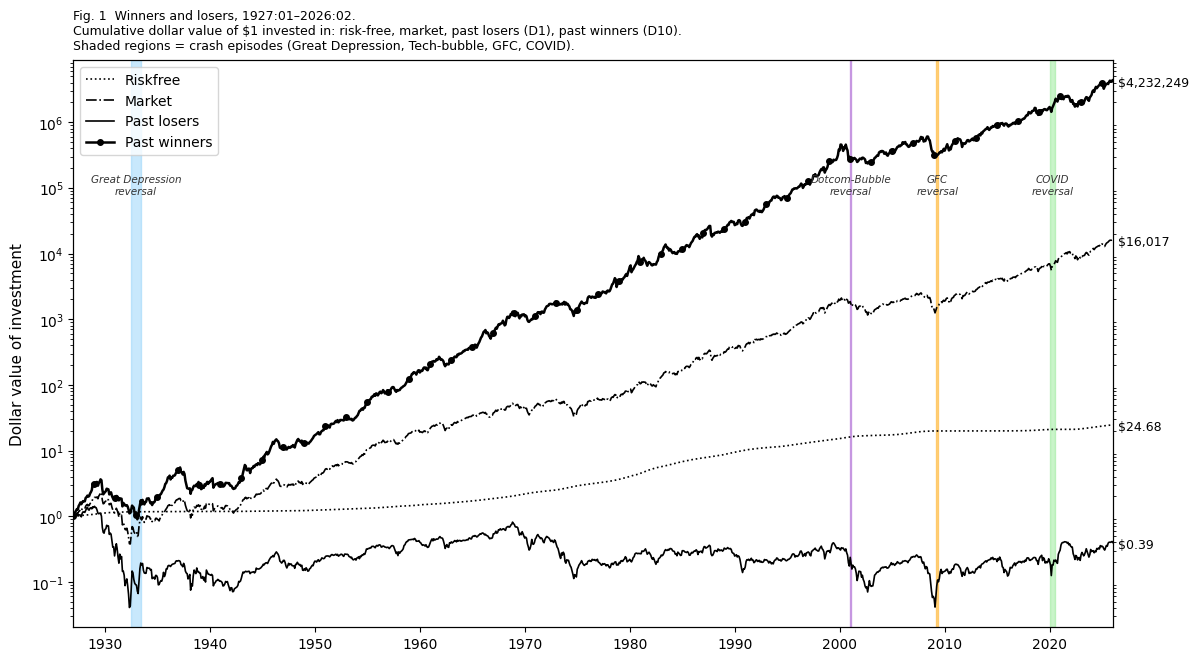

In [3]:
# Figure 1: Winners and Losers (cumulative wealth, log scale)

# Sorting the data chronologically to fix timeline for plot
data_m = data_m.sort_index()

# Gross monthly returns (total return, not excess)
gross_rf  = 1 + data_m["RF"]
gross_mkt = 1 + data_m["Mkt-RF"] + data_m["RF"]
gross_d1  = 1 + data_m["D1"]
gross_d10 = 1 + data_m["D10"]

# Cumulative wealth starting at $1
cum_rf  = gross_rf.cumprod()
cum_mkt = gross_mkt.cumprod()
cum_d1  = gross_d1.cumprod()
cum_d10 = gross_d10.cumprod()

# Four crash episodes with shaded bands
crash_periods = [
    ("1932-07", "1933-05", "Great Depression\nreversal"),
    ("2001-01", "2001-01", "Dotcom-Bubble\nreversal"),
    ("2009-03", "2009-05", "GFC\nreversal"),
    ("2020-02", "2020-06", "COVID\nreversal"),
]

# Plot
fig, ax = plt.subplots(figsize=(13, 7))

ax.semilogy(cum_rf.index,  cum_rf.values,  "k:",   lw=1.2, label="Riskfree")
ax.semilogy(cum_mkt.index, cum_mkt.values, "k-.", lw=1.2, label="Market")
ax.semilogy(cum_d1.index,  cum_d1.values,  "k-",  lw=1.2, label="Past losers")
ax.semilogy(cum_d10.index, cum_d10.values, "k-",  lw=1.8,
            marker="o", markevery=24, markersize=4, label="Past winners")

# Crash shading + period labels
shade_colors = ["#87cefa", "#9d4ccc", "#ffa500", "#88e788"]
for (start, end, label), color in zip(crash_periods, shade_colors):
    t0 = pd.Timestamp(start)
    t1 = pd.Timestamp(end) + pd.offsets.MonthEnd(1)
    ax.axvspan(t0, t1, alpha=0.45, color=color, zorder=0)
    mid = t0 + (t1 - t0) / 2
    ax.text(mid, 160000, label, ha="center", va="top", fontsize=7.5,
            color="#333333", style="italic")

# Right axis: final dollar values
final_vals = [
    (cum_d10.iloc[-1], f"${cum_d10.iloc[-1]:,.0f}"),
    (cum_mkt.iloc[-1], f"${cum_mkt.iloc[-1]:,.0f}"),
    (cum_rf.iloc[-1],  f"${cum_rf.iloc[-1]:.2f}"),
    (cum_d1.iloc[-1],  f"${cum_d1.iloc[-1]:.2f}"),
]
right_ax = ax.twinx()
right_ax.set_yscale("log")
# Set y-limits from data (ax.get_ylim() is unreliable before draw)
all_vals = np.concatenate([cum_rf.values, cum_mkt.values, cum_d1.dropna().values, cum_d10.values])
ymin = all_vals[all_vals > 0].min() * 0.5
ymax = all_vals.max() * 2.0
ax.set_ylim(ymin, ymax)
right_ax.set_ylim(ymin, ymax)
right_ax.set_yticks([v for v, _ in final_vals])
right_ax.set_yticklabels([lbl for _, lbl in final_vals], fontsize=9)
right_ax.tick_params(axis="y", length=0)

# Axes formatting
ax.set_ylabel("Dollar value of investment", fontsize=11)
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlim(cum_rf.index[0], cum_rf.index[-1])
ax.legend(loc="upper left", fontsize=10, frameon=True)

start_label = data_m.index[0].strftime("%Y:%m")
end_label   = data_m.index[-1].strftime("%Y:%m")
ax.set_title(
    f'Fig. 1  Winners and losers, {start_label}\u2013{end_label}.\n'
    'Cumulative dollar value of $1 invested in: risk-free, market, past losers (D1), past winners (D10).\n'
    "Shaded regions = crash episodes (Great Depression, Tech-bubble, GFC, COVID).",
    fontsize=9, loc='left', pad=8
)

fig.subplots_adjust(left=0.07, right=0.87, top=0.88, bottom=0.07)
plt.show()

## Table 2 – Worst Monthly Momentum Returns

The 15 worst monthly returns to the WML momentum portfolio over the full sample.
Also tabulated are:
- **MKT-2y**: cumulative market return over the 24 months *prior* to the portfolio formation date
  (i.e. $\prod_{s=t-24}^{t-1}(1+r_{m,s}) - 1$)
- **Mkt*: contemporaneous total market return in month $ (Mkt-RF + RF)

All numbers in percent. Period markers:
-  July 1932 – September 1939 (Great Depression reversal)
-  April 2009 – August 2009 (GFC reversal)
-  January 2001 – November 2002 (Dotcom-bubble reversal)
-  February 2020 – June 2020 (COVID reversal)


In [4]:
# Table 2: 15 worst WML months

# Two-year cumulative market return ending the month before t
mkt_gross = 1 + data_m['Mkt-RF'] + data_m['RF']
data_m['MKT-2y'] = mkt_gross.rolling(24).apply(np.prod, raw=True).shift(1) - 1
data_m['Mkt_t']  = data_m['Mkt-RF'] + data_m['RF']   # contemporaneous total market return

# 15 worst WML months, sorted ascending
worst15_idx = data_m['WML'].nsmallest(15).sort_values().index

# Period markers
def marker(dt):
    if pd.Timestamp('1932-07') <= dt <= pd.Timestamp('1939-09'): return '*'
    if pd.Timestamp('2009-04') <= dt <= pd.Timestamp('2009-08'): return '†'  # †
    if pd.Timestamp('2001-01') <= dt <= pd.Timestamp('2002-11'): return '‡'  # ‡
    if pd.Timestamp('2020-02') <= dt <= pd.Timestamp('2020-06'): return '§'  # §
    return ''

rows = []
for rank, dt in enumerate(worst15_idx, 1):
    # Calculate the concurrent EXCESS returns for month t
    wml_t   = data_m.loc[dt, 'WML']
    mkt_ex  = data_m.loc[dt, 'Mkt-RF']               # Use excess market return
    d1_ex   = data_m.loc[dt, 'D1'] - data_m.loc[dt, 'RF']  # Subtract RF from losers
    d10_ex  = data_m.loc[dt, 'D10'] - data_m.loc[dt, 'RF'] # Subtract RF from winners
    
    rows.append({
        'Rank':    rank,
        'Month':   dt.strftime('%Y:%m') + marker(dt),
        'WML_t':   wml_t  * 100,
        'MKT-2y':  data_m.loc[dt, 'MKT-2y'] * 100,
        'Mkt_t':   mkt_ex * 100,
        'D1_t':    d1_ex  * 100,
        'D10_t':   d10_ex * 100,
    })

tab2 = pd.DataFrame(rows).set_index('Rank')

start_yr = data_m.index[0].strftime('%Y:%m')
end_yr   = data_m.index[-1].strftime('%Y:%m')
print(f'Table 2 – Worst monthly momentum returns, {start_yr}–{end_yr}')

tab2.style.format({
    'WML_t':  '{:.2f}',
    'MKT-2y': '{:.2f}',
    'Mkt_t':  '{:.2f}',
    'D1_t':   '{:.2f}',
    'D10_t':  '{:.2f}',
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'right')]},
    {'selector': 'td', 'props': [('text-align', 'right')]},
]).set_caption(
    f'Table 2: 15 worst WML months, {start_yr}–{end_yr}. '
    '* = Great Depression (1932:07–1939:09), '
    '† = GFC (2009:04–2009:08), '
    '‡ = Dotcom (2001:01–2002:11), '
    '§ = COVID (2020:02–2020:06). All values in %.'
)


Table 2 – Worst monthly momentum returns, 1927:01–2026:02


,Month,WML_t,MKT-2y,Mkt_t,D1_t,D10_t
Rank,,,,,,
1,1932:08*,-78.04,-67.57,37.12,93.81,15.77
2,1932:07*,-63.04,-74.69,33.61,74.92,11.88
3,2009:04†,-45.32,-40.49,10.17,45.19,-0.13
4,1939:09*,-44.36,-21.87,16.89,52.27,7.91
5,2001:01‡,-41.71,10.72,3.25,35.18,-6.53
6,2009:03,-39.18,-44.79,9.01,44.63,5.45
7,1938:06*,-33.47,-28.17,23.89,43.58,10.11
8,2020:04§,-31.69,-0.74,13.60,46.12,14.43
9,1933:04*,-31.53,-58.97,38.81,60.11,28.58


## Table 3 – Market Timing Regression

Replication of Daniel & Moskowitz (2016), Table 3. The dependent variable is the monthly WML excess return.
The full regression model is:

$$R_{WML,t} = \hat{\alpha}_0 + \hat{\alpha}_B I_{B,t-1} + \hat{\beta}_0 \tilde{R}^e_{m,t} + \hat{\beta}_B (I_{B,t-1} \cdot \tilde{R}^e_{m,t}) + \hat{\beta}_{B,U} (I_{B,t-1} \cdot I_{U,t} \cdot \tilde{R}^e_{m,t}) + \epsilon_t$$

### Variable definitions

| Symbol | Definition |
| :--- | :--- |
| $I_{B,t-1}$ | **Bear-market indicator:** equals 1 if the cumulative market return over the 24 months *prior* to $t$ is negative, i.e. $\prod_{s=t-24}^{t-1}(1 + R^e_{m,s} + R_{f,s}) - 1 < 0$ |
| $\tilde{R}^e_{m,t}$ | Contemporaneous **excess market return** $R^e_{m,t} = R_{m,t} - R_{f,t}$ |
| $I_{U,t}$ | **Up-market indicator:** equals 1 if $R^e_{m,t} > 0$ |
| $\hat{\alpha}_0$ | Unconditional WML intercept ($\times 100$, in % per month) |
| $\hat{\alpha}_B$ | Incremental intercept in bear markets ($\times 100$, in % per month) |
| $\hat{\beta}_0$ | Unconditional market beta |
| $\hat{\beta}_B$ | Incremental beta in bear markets |
| $\hat{\beta}_{B,U}$ | Additional incremental beta in bear + up markets |

The four specifications include progressively more interaction terms. All $t$-statistics use Newey-West standard errors with 6 lags.


In [5]:
# Table 3: Market timing regression

# Construct regression variables
# Bear-market indicator: I_B,t-1 = 1 if 2-year cumulative market return < 0
mkt_gross_2y = 1 + data_m['Mkt-RF'] + data_m['RF']
mkt_2y       = mkt_gross_2y.rolling(24).apply(np.prod, raw=True).shift(1) - 1
data_m['I_B'] = np.where(mkt_2y.isna(), np.nan, (mkt_2y < 0).astype(float))
data_m['Rm']   = data_m['Mkt-RF']                     # R^e_{m,t}
data_m['I_U']  = (data_m['Rm'] > 0).astype(float)    # I_{U,t}

# Interaction terms
data_m['I_B_Rm']       = data_m['I_B'] * data_m['Rm']                        # I_{B,t-1} * R^e_{m,t}
data_m['I_B_I_U_Rm']   = data_m['I_B'] * data_m['I_U'] * data_m['Rm']       # I_{B,t-1} * I_{U,t} * R^e_{m,t}

# NW OLS helper (multi-regressor)
def nw_ols_multi_efficient(y_col, x_cols, data, lags=6):
    """
    OLS of y on [1, x_cols] with memory-efficient Newey-West SEs (Bartlett, `lags` lags).
    Returns (coefficients, t-statistics, adj-R2).
    """
    # 1. Clean data and construct matrices
    df = data[[y_col] + x_cols].dropna()
    y  = df[y_col].values
    X  = np.column_stack([np.ones(len(df)), df[x_cols].values])
    n, k = len(y), X.shape[1] - 1
    
    # 2. OLS Coefficients and Residuals
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    e = y - X @ b
    
    # 3. Efficient Newey-West Covariance (HC0 + Lags)
    # Broadast the residuals element-wise across the columns of X
    # avoids creating an N x N diagonal matrix
    Xe = X * e[:, None] 
    
    # Contemporaneous variance (Lag 0)
    S = Xe.T @ Xe
    
    # Lagged covariances (Bartlett kernel)
    for lag in range(1, lags + 1):
        G = Xe[lag:].T @ Xe[:-lag]
        w = 1 - lag / (lags + 1)
        S += w * (G + G.T)
        
    # Sandwich estimator: V = (X'X)^-1 * S * (X'X)^-1
    XX_inv = np.linalg.inv(X.T @ X)
    V = XX_inv @ S @ XX_inv
    
    # 4. Extract Statistics
    t_stat = b / np.sqrt(np.diag(V))
    
    ss_res = np.sum(e**2)
    ss_tot = np.sum((y - y.mean())**2)
    # Handle the edge case where variance is zero to avoid division by zero
    if ss_tot == 0:
        r2_adj = 0.0
    else:
        r2_adj = 1 - (ss_res / (n - k - 1)) / (ss_tot / (n - 1))
        
    return b, t_stat, r2_adj

# Run four specifications
specs = [
    # (label, x_cols)
    ('(1)', ['Rm']),
    ('(2)', ['I_B', 'Rm', 'I_B_Rm']),
    ('(3)', ['I_B', 'Rm', 'I_B_Rm', 'I_B_I_U_Rm']),
    ('(4)', ['Rm', 'I_B_Rm', 'I_B_I_U_Rm']),
]

results = {}
for name, xcols in specs:
    b, t, r2 = nw_ols_multi('WML', xcols, data_m, lags=6)
    results[name] = {'b': b, 't': t, 'r2': r2, 'xcols': xcols}

# Format into Table 3 (coef row + t-stat row per variable)
# Columns map: intercept=a0, I_B=aB, Rm=b0, I_B_Rm=bB, I_B_I_U_Rm=bBU
coef_map = [
    ('intercept', r'$\hat{\alpha}_0$',    r'$1$',                                              True),
    ('I_B',       r'$\hat{\alpha}_B$',    r'$I_{B,t-1}$',                                      True),
    ('Rm',        r'$\hat{\beta}_0$',     r'$\tilde{R}^e_{m,t}$',                              False),
    ('I_B_Rm',    r'$\hat{\beta}_B$',     r'$I_{B,t-1}\cdot\tilde{R}^e_{m,t}$',              False),
    ('I_B_I_U_Rm',r'$\hat{\beta}_{B,U}$', r'$I_{B,t-1}\cdot I_{U,t}\cdot\tilde{R}^e_{m,t}$', False),
]

spec_names = list(results.keys())
coef_rows  = []   # coefficient values
tstat_rows = []   # t-statistics
index_labels = [] # row index: (coef_label, sub-row)

for var_key, coef_label, var_label, scale in coef_map:
    coef_row  = {}
    tstat_row = {}
    for spec_name, res in results.items():
        xcols = res['xcols']
        b, t  = res['b'], res['t']
        if var_key == 'intercept':
            idx = 0
        elif var_key in xcols:
            idx = xcols.index(var_key) + 1
        else:
            coef_row[spec_name]  = ''
            tstat_row[spec_name] = ''
            continue
        val  = b[idx] * 100 if scale else b[idx]
        tval = t[idx]
        coef_row[spec_name]  = f'{val:.3f}'
        tstat_row[spec_name] = f'({tval:.1f})'
    coef_rows.append(coef_row)
    tstat_rows.append(tstat_row)
    index_labels.append((coef_label, 'coef'))
    index_labels.append((coef_label, 't-stat'))

# Interleave coef and t-stat rows
all_rows = []
for c, t in zip(coef_rows, tstat_rows):
    all_rows.append(c)
    all_rows.append(t)

# R2 adj row (single row, no t-stat)
r2_row = {s: f"{results[s]['r2']:.3f}" for s in spec_names}
index_labels.append((r'$R^2_{adj}$', ''))
all_rows.append(r2_row)

idx = pd.MultiIndex.from_tuples(index_labels, names=['Coefficient', ''])
tab3 = pd.DataFrame(all_rows, index=idx)

start_yr = data_m.index[0].strftime('%Y:%m')
end_yr   = data_m.index[-1].strftime('%Y:%m')
print(f'Table 3 – Market timing regression, {start_yr}\u2013{end_yr}')
print('alpha_0 and alpha_B x100 (% per month). t-stats (NW, 6 lags) in parentheses.')
tab3


NameError: name 'nw_ols_multi' is not defined

## Table 4 - Momentum Portfolio Optionality

Replication of Daniel & Moskowitz (2016), Table 4. Each column runs a time-series regression of the **monthly excess return** of a momentum decile portfolio (or WML) on the excess market return and indicator variables.

**Panel A - Optionality in bear markets:**

$$\tilde{R}^e_{i,t} = \bigl[{\alpha}_0 + {\alpha}_B I_{B,t-1}\bigr] + \bigl[{\beta}_0 + I_{B,t-1}({\beta}_B + \tilde{I}_{U,t}{\beta}_{B,U})\bigr]\tilde{R}^e_{m,t} + \tilde{\epsilon}_t$$

**Panel B - Optionality in bull markets:**

$$\tilde{R}^e_{i,t} = \bigl[{\alpha}_0 + {\alpha}_L I_{L,t-1}\bigr] + \bigl[{\beta}_0 + I_{L,t-1}({\beta}_L + \tilde{I}_{U,t}{\beta}_{L,U})\bigr]\tilde{R}^e_{m,t} + \tilde{\epsilon}_t$$

### Variable definitions

| Symbol | Definition |
| :--- | :--- |
| $I_{B,t-1}$ | **Bear indicator:** 1 if 24-month cumulative market return before $t$ is negative |
| $I_{L,t-1}$ | **Bull indicator:** $1 - I_{B,t-1}$ |
| $\tilde{R}^e_{m,t}$ | Contemporaneous excess market return |
| $I_{U,t}$ | **Up-market indicator:** 1 if $R^e_{m,t} > 0$ |
| $\hat{\alpha}_0, \hat{\alpha}_B, \hat{\alpha}_L$ | Intercepts (x100, % per month) |
| $\hat{\beta}_0$ | Unconditional market beta |
| $\hat{\beta}_B, \hat{\beta}_{B,U}$ | Incremental betas in bear / bear+up markets |
| $\hat{\beta}_L, \hat{\beta}_{L,U}$ | Incremental betas in bull / bull+up markets |

All $t$-statistics use Newey-West standard errors with 6 lags.

In [ ]:
# Table 4: Momentum portfolio optionality

# Indicators and interaction terms
mkt_gross_t4 = 1 + data_m['Mkt-RF'] + data_m['RF']
mkt_2y_t4    = mkt_gross_t4.rolling(24).apply(np.prod, raw=True).shift(1) - 1
data_m['I_B_t4']  = (mkt_2y_t4 < 0).astype(float)   # bear: 2y cum mkt return < 0
data_m['I_B_t4'] = np.where(mkt_2y_t4.isna(), np.nan, (mkt_2y_t4 < 0).astype(float))
data_m['I_L_t4'] = np.where(mkt_2y_t4.isna(), np.nan, 1 - data_m['I_B_t4'])
data_m['Rm_t4']   = data_m['Mkt-RF']                  # excess market return
data_m['I_U_t4']  = (data_m['Rm_t4'] > 0).astype(float)  # up-market

# Panel A regressors: I_B, Rm, I_B*Rm, I_B*I_U*Rm
data_m['I_B_Rm_t4']     = data_m['I_B_t4'] * data_m['Rm_t4']
data_m['I_B_IU_Rm_t4']  = data_m['I_B_t4'] * data_m['I_U_t4'] * data_m['Rm_t4']

# Panel B regressors: I_L, Rm, I_L*Rm, I_L*I_U*Rm
data_m['I_L_Rm_t4']     = data_m['I_L_t4'] * data_m['Rm_t4']
data_m['I_L_IU_Rm_t4']  = data_m['I_L_t4'] * data_m['I_U_t4'] * data_m['Rm_t4']

# NW OLS (multi-regressor, returns b and t-stat arrays)
def nw_ols_t4(y_arr, X_arr, lags=6):
    mask = ~(np.isnan(y_arr) | np.any(np.isnan(X_arr), axis=1))
    y, X = y_arr[mask], X_arr[mask]
    n = len(y)
    Xd = np.column_stack([np.ones(n), X])
    b  = np.linalg.lstsq(Xd, y, rcond=None)[0]
    e  = y - Xd @ b
    
    # Efficient NW Covariance
    Xe = Xd * e[:, None]
    S  = Xe.T @ Xe
    for lag in range(1, lags + 1):
        G = Xe[lag:].T @ Xe[:-lag]
        S += (1 - lag / (lags + 1)) * (G + G.T)
        
    XX_inv = np.linalg.inv(Xd.T @ Xd)
    V = XX_inv @ S @ XX_inv
    return b, b / np.sqrt(np.diag(V))

# Run regressions for all portfolios
portfolios_t4 = [f'D{i}' for i in range(1, 11)] + ['WML']
col_labels_t4 = [str(i) for i in range(1, 11)] + ['WML']

X_A = data_m[['I_B_t4', 'Rm_t4', 'I_B_Rm_t4', 'I_B_IU_Rm_t4']].values
X_B = data_m[['I_L_t4', 'Rm_t4', 'I_L_Rm_t4', 'I_L_IU_Rm_t4']].values

# coef index: 0=intercept, 1=I_B/I_L, 2=Rm, 3=I_B*Rm/I_L*Rm, 4=I_B*I_U*Rm/I_L*I_U*Rm
# scale *100 for intercepts (indices 0,1)
panels = {
    'Panel A: Optionality in bear markets': (
        X_A,
        [r'$\hat{\alpha}_0$', r'$\hat{\alpha}_B$',
         r'$\hat{\beta}_0$',  r'$\hat{\beta}_B$', r'$\hat{\beta}_{B,U}$'],
        [True, True, False, False, False]
    ),
    'Panel B: Optionality in bull markets': (
        X_B,
        [r'$\hat{\alpha}_0$', r'$\hat{\alpha}_L$',
         r'$\hat{\beta}_0$',  r'$\hat{\beta}_L$', r'$\hat{\beta}_{L,U}$'],
        [True, True, False, False, False]
    ),
}

# Build and display each panel
start_yr = data_m.index[0].strftime('%Y:%m')
end_yr   = data_m.index[-1].strftime('%Y:%m')
print(f'Table 4 – Momentum portfolio optionality, {start_yr}\u2013{end_yr}')
print('Intercepts x100 (% per month). t-stats (NW, 6 lags) in parentheses.')

for panel_title, (X_mat, coef_labels, scale_flags) in panels.items():
    # Collect results
    bs = {}; ts = {}
    for port in portfolios_t4:
        # Subtract the risk-free rate for D1 through D10, but NOT for WML
        if port == 'WML':
            y_val = data_m[port].values
        else:
            y_val = (data_m[port] - data_m['RF']).values
            
        b, t = nw_ols_t4(y_val, X_mat)
        bs[port] = b; ts[port] = t

    # Build alternating coef / t-stat rows
    all_rows = []; idx_labels = []
    for ci, (clabel, sc) in enumerate(zip(coef_labels, scale_flags)):
        coef_row  = {cl: f"{bs[p][ci]*100 if sc else bs[p][ci]:.3f}"
                     for p, cl in zip(portfolios_t4, col_labels_t4)}
        tstat_row = {cl: f"({ts[p][ci]:.1f})"
                     for p, cl in zip(portfolios_t4, col_labels_t4)}
        all_rows += [coef_row, tstat_row]
        idx_labels += [(clabel, 'coef'), (clabel, 't-stat')]

    midx = pd.MultiIndex.from_tuples(idx_labels, names=['Coefficient', ''])
    panel_df = pd.DataFrame(all_rows, index=midx)

    print(f'\n{panel_title}')
    display(panel_df)


## Figure 4 – Ex Ante vs Ex Post Hedged Momentum

Replication of Daniel & Moskowitz (2016), Figure 4. Cumulative returns to three momentum strategies (log scale):

1. **Unhedged** (solid): static WML = D10 − D1
2. **Ex post hedged** (dotted): WML hedged using the *future* 6-month realized beta — an infeasible benchmark
3. **Ex ante hedged** (dashed): WML hedged using the *lagged* 6-month realized beta — a feasible strategy

The hedged return in month $t$ is:
$$r^{\text{hedged}}_t = r^{\text{WML}}_t - \hat{\beta}_t \cdot R^e_{m,t}$$

where $\hat{\beta}_t$ is estimated from a 6-month rolling window of WML and market excess returns (lagged for ex ante, leading for ex post).

**Panel A** covers the Great Depression period (1927–1939). **Panel B** covers the full sample.


In [ ]:
# Figure 4: Ex ante vs ex post hedged momentum (42-day rolling beta)

# Compute 42-day rolling betas using daily data
# For each month t:
#   Ex ante beta: cov/var from the 42 trading days before month t
#   Ex post beta:  cov/var from the 42 trading days starting at month t
# Then hedge the monthly WML return: hedged_t = WML_t - beta_t * Mkt_t

# Daily WML and market (already loaded in data_d from cell above)
data_d_sorted = data_d.sort_index() if 'data_d' in locals() else None
try:
    _ = data_d.index[0]
except:
    mom_d = pd.read_csv('data/10_Portfolios_Prior_12_2_Daily.csv',
                        skiprows=9, index_col=0, header=0)
    mom_d.index = mom_d.index.astype(str).str.strip()
    mom_d = mom_d[mom_d.index.str.match(r'^\d{8}$')]
    mom_d.index = pd.to_datetime(mom_d.index, format='%Y%m%d')
    mom_d.columns = [f'D{i}' for i in range(1, 11)]
    mom_d = mom_d.apply(pd.to_numeric, errors='coerce').replace([-99.99, -999], np.nan) / 100
    
    ff_d = pd.read_csv('data/F-F_Research_Data_Factors_daily.csv', skiprows=4, index_col=0)
    ff_d.index = ff_d.index.astype(str).str.strip()
    ff_d = ff_d[ff_d.index.str.match(r'^\d{8}$')]
    ff_d.index = pd.to_datetime(ff_d.index, format='%Y%m%d')
    ff_d = ff_d.apply(pd.to_numeric, errors='coerce') / 100
    
    data_d = mom_d.join(ff_d, how='inner').sort_index()
    data_d['WML'] = data_d['D10'] - data_d['D1']

# Daily arrays
wml_daily = data_d['WML'].values
mkt_daily = data_d['Mkt-RF'].values
daily_dates = data_d.index

# Monthly arrays
monthly_dates = data_m.index
wml_m = data_m['WML'].values
mkt_m = data_m['Mkt-RF'].values
n_m = len(monthly_dates)

# Construct the 10-day lagged market matrix (Dimson Beta Setup)
n_days = len(mkt_daily)
X_mkt_lags = np.full((n_days, 11), np.nan)
for lag in range(11):
    if lag == 0:
        X_mkt_lags[:, lag] = mkt_daily
    else:
        X_mkt_lags[lag:, lag] = mkt_daily[:-lag]

# Compute 42-day betas for each month
beta_exante_42 = np.full(n_m, np.nan)
beta_expost_42 = np.full(n_m, np.nan)

for i, mdate in enumerate(monthly_dates):
    d_idx = daily_dates.searchsorted(mdate)
    
    # Ex ante: 42 trading days BEFORE month t
    s, e = max(0, d_idx - 42), d_idx
    if e - s >= 20:
        w_curr = wml_daily[s:e]
        X_curr = X_mkt_lags[s:e]
        
        # Drop rows with NaNs (mostly due to the 10-day lags)
        valid = ~(np.isnan(w_curr) | np.any(np.isnan(X_curr), axis=1))
        if valid.sum() >= 20:
            y_clean = w_curr[valid]
            X_clean = X_curr[valid]
            
            # OLS: y = X * b  (Include intercept)
            X_design = np.column_stack([np.ones(len(X_clean)), X_clean])
            b_exante = np.linalg.lstsq(X_design, y_clean, rcond=None)[0]
            
            # The total beta is the sum of the 11 market coefficients (exclude intercept)
            beta_exante_42[i] = np.sum(b_exante[1:])
            
    # Ex post: 42 trading days FROM START of month t
    s2, e2 = d_idx, min(len(daily_dates), d_idx + 42)
    if e2 - s2 >= 20:
        w_curr2 = wml_daily[s2:e2]
        X_curr2 = X_mkt_lags[s2:e2]
        
        valid2 = ~(np.isnan(w_curr2) | np.any(np.isnan(X_curr2), axis=1))
        if valid2.sum() >= 20:
            y_clean2 = w_curr2[valid2]
            X_clean2 = X_curr2[valid2]
            
            X_design2 = np.column_stack([np.ones(len(X_clean2)), X_clean2])
            b_expost = np.linalg.lstsq(X_design2, y_clean2, rcond=None)[0]
            
            beta_expost_42[i] = np.sum(b_expost[1:])

# Hedged monthly returns
hedged_exante = wml_m - np.where(np.isnan(beta_exante_42), 0, beta_exante_42) * mkt_m
hedged_expost = wml_m - np.where(np.isnan(beta_expost_42), 0, beta_expost_42) * mkt_m

# Cumulative wealth
cum_wml    = np.cumprod(1 + np.nan_to_num(wml_m))
cum_exante = np.cumprod(1 + np.nan_to_num(hedged_exante))
cum_expost = np.cumprod(1 + np.nan_to_num(hedged_expost))
dates = monthly_dates

# Plot Panel A + Panel B
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Panel A: Great Depression (1927:06 – 1939:12)
mask_a = (dates >= '1927-06') & (dates <= '1939-12')
ax1.semilogy(dates[mask_a], cum_wml[mask_a],    'k-',  lw=1.5, label='Unhedged')
ax1.semilogy(dates[mask_a], cum_expost[mask_a], 'k:',  lw=1.5, label='Ex post hedged')
ax1.semilogy(dates[mask_a], cum_exante[mask_a], 'k--', lw=1.5, label='Ex ante hedged')
ax1.set_ylabel('Portfolio value', fontsize=11)
ax1.legend(loc='upper left', fontsize=10)
ax1.set_title(
    f'Panel A: Cumulative monthly returns, '
    f'{dates[mask_a][0].strftime("%Y:%m")}\u2013{dates[mask_a][-1].strftime("%Y:%m")}',
    fontsize=10, loc='left'
)
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel B: Full sample
ax2.semilogy(dates, cum_wml,    'k-',  lw=1.5, label='Unhedged')
ax2.semilogy(dates, cum_expost, 'k:',  lw=1.5, label='Ex post hedged')
ax2.semilogy(dates, cum_exante, 'k--', lw=1.5, label='Ex ante hedged')
ax2.set_ylabel('Portfolio value', fontsize=11)
ax2.legend(loc='upper left', fontsize=10)
ax2.set_title(
    f'Panel B: Cumulative monthly returns, '
    f'{dates[0].strftime("%Y:%m")}\u2013{dates[-1].strftime("%Y:%m")}',
    fontsize=10, loc='left'
)
ax2.xaxis.set_major_locator(mdates.YearLocator(10))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.subplots_adjust(hspace=0.3, left=0.08, right=0.95, top=0.95, bottom=0.06)
plt.show()


In [ ]:
# Figure 4 (continued): GFC and COVID crash episodes (Without Shading)
# Same three strategies, zoomed into ~12-year windows, rebased to 1

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Panel C: GFC period (2003-01 to 2015-12)
mask_gfc = (dates >= '2003-01') & (dates <= '2015-12')
i0_gfc = np.where(mask_gfc)[0][0]

# Rebase to 1 at the start of the period
cum_wml_gfc    = cum_wml[mask_gfc]    / cum_wml[i0_gfc]
cum_expost_gfc = cum_expost[mask_gfc] / cum_expost[i0_gfc]
cum_exante_gfc = cum_exante[mask_gfc] / cum_exante[i0_gfc]

ax1.semilogy(dates[mask_gfc], cum_wml_gfc,    'k-',  lw=1.5, label='Unhedged')
ax1.semilogy(dates[mask_gfc], cum_expost_gfc, 'k:',  lw=1.5, label='Ex post hedged')
ax1.semilogy(dates[mask_gfc], cum_exante_gfc, 'k--', lw=1.5, label='Ex ante hedged')

ax1.set_ylabel('Portfolio value (rebased to 1)', fontsize=11)
ax1.legend(loc='upper left', fontsize=10)
ax1.set_title('Panel C: GFC reversal period, 2003:01–2015:12', fontsize=10, loc='left')
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel D: COVID period (2014-01 to 2026-12)
mask_covid = (dates >= '2014-01') & (dates <= '2026-12')
i0_covid = np.where(mask_covid)[0][0]

# Rebase to 1 at the start of the period
cum_wml_covid    = cum_wml[mask_covid]    / cum_wml[i0_covid]
cum_expost_covid = cum_expost[mask_covid] / cum_expost[i0_covid]
cum_exante_covid = cum_exante[mask_covid] / cum_exante[i0_covid]

ax2.semilogy(dates[mask_covid], cum_wml_covid,    'k-',  lw=1.5, label='Unhedged')
ax2.semilogy(dates[mask_covid], cum_expost_covid, 'k:',  lw=1.5, label='Ex post hedged')
ax2.semilogy(dates[mask_covid], cum_exante_covid, 'k--', lw=1.5, label='Ex ante hedged')

ax2.set_ylabel('Portfolio value (re,based to 1)', fontsize=11)
ax2.legend(loc='upper left', fontsize=10)
ax2.set_title(
    f'Panel D: COVID reversal period, 2014:01–{dates[mask_covid][-1].strftime("%Y:%m")}',
    fontsize=10, loc='left'
)
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.subplots_adjust(hspace=0.3, left=0.08, right=0.95, top=0.95, bottom=0.06)
plt.show()

In [ ]:
# 1. Initialize arrays (assuming X_mkt_lags, wml_daily, daily_dates are still in memory from Figure 4)
window_126d = 126  # Approx 6 months of trading days
beta_exante_6m = np.full(n_m, np.nan)
beta_expost_6m = np.full(n_m, np.nan)

# 2. Compute 6-month (126-day) Dimson-betas for each month using DAILY data
for i, mdate in enumerate(monthly_dates):
    d_idx = daily_dates.searchsorted(mdate)
    
    # Ex ante: 126 trading days BEFORE month t
    s, e = max(0, d_idx - window_126d), d_idx
    if e - s >= 60: # Require at least ~3 months of valid daily data
        w_curr = wml_daily[s:e]
        X_curr = X_mkt_lags[s:e]
        
        valid = ~(np.isnan(w_curr) | np.any(np.isnan(X_curr), axis=1))
        if valid.sum() >= 60:
            y_clean = w_curr[valid]
            X_clean = X_curr[valid]
            X_design = np.column_stack([np.ones(len(X_clean)), X_clean])
            b_exante = np.linalg.lstsq(X_design, y_clean, rcond=None)[0]
            beta_exante_6m[i] = np.sum(b_exante[1:])
            
    # Ex post: 126 trading days FROM START of month t
    s2, e2 = d_idx, min(len(daily_dates), d_idx + window_126d)
    if e2 - s2 >= 60:
        w_curr2 = wml_daily[s2:e2]
        X_curr2 = X_mkt_lags[s2:e2]
        
        valid2 = ~(np.isnan(w_curr2) | np.any(np.isnan(X_curr2), axis=1))
        if valid2.sum() >= 60:
            y_clean2 = w_curr2[valid2]
            X_clean2 = X_curr2[valid2]
            X_design2 = np.column_stack([np.ones(len(X_clean2)), X_clean2])
            b_expost = np.linalg.lstsq(X_design2, y_clean2, rcond=None)[0]
            beta_expost_6m[i] = np.sum(b_expost[1:])

# 3. Calculate Monthly Hedged Returns (exactly as you had it)
hedged_exante_6m = wml_m - np.where(np.isnan(beta_exante_6m), 0, beta_exante_6m) * mkt_m
hedged_expost_6m = wml_m - np.where(np.isnan(beta_expost_6m), 0, beta_expost_6m) * mkt_m

cum_exante_6m = np.cumprod(1 + np.nan_to_num(hedged_exante_6m))
cum_expost_6m = np.cumprod(1 + np.nan_to_num(hedged_expost_6m))

# Plot: 4 panels comparing 42-day vs 6-month lag
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel A: Great Depression – 42-day lag
ax = axes[0, 0]
mask_a = (dates >= '1927-06') & (dates <= '1939-12')
ax.semilogy(dates[mask_a], cum_wml[mask_a],    'k-',  lw=1.5, label='Unhedged')
ax.semilogy(dates[mask_a], cum_expost[mask_a], 'k:',  lw=1.5, label='Ex post (42d)')
ax.semilogy(dates[mask_a], cum_exante[mask_a], 'k--', lw=1.5, label='Ex ante (42d)')
ax.set_ylabel('Portfolio value', fontsize=10)
ax.legend(loc='upper right', fontsize=8)
ax.set_title('Panel A: Depression, 42-day beta', fontsize=10, loc='left')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel B: Great Depression – 6-month lag
ax = axes[0, 1]
ax.semilogy(dates[mask_a], cum_wml[mask_a],       'k-',  lw=1.5, label='Unhedged')
ax.semilogy(dates[mask_a], cum_expost_6m[mask_a], 'k:',  lw=1.5, label='Ex post (6m)')
ax.semilogy(dates[mask_a], cum_exante_6m[mask_a], 'k--', lw=1.5, label='Ex ante (6m)')
ax.set_ylabel('Portfolio value', fontsize=10)
ax.legend(loc='upper right', fontsize=8)
ax.set_title('Panel B: Depression, 6-month beta', fontsize=10, loc='left')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel C: Full sample – 42-day lag
ax = axes[1, 0]
ax.semilogy(dates, cum_wml,    'k-',  lw=1.5, label='Unhedged')
ax.semilogy(dates, cum_expost, 'k:',  lw=1.5, label='Ex post (42d)')
ax.semilogy(dates, cum_exante, 'k--', lw=1.5, label='Ex ante (42d)')
ax.set_ylabel('Portfolio value', fontsize=10)
ax.legend(loc='upper left', fontsize=8)
ax.set_title('Panel C: Full sample, 42-day beta', fontsize=10, loc='left')
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel D: Full sample – 6-month lag
ax = axes[1, 1]
ax.semilogy(dates, cum_wml,       'k-',  lw=1.5, label='Unhedged')
ax.semilogy(dates, cum_expost_6m, 'k:',  lw=1.5, label='Ex post (6m)')
ax.semilogy(dates, cum_exante_6m, 'k--', lw=1.5, label='Ex ante (6m)')
ax.set_ylabel('Portfolio value', fontsize=10)
ax.legend(loc='upper left', fontsize=8)
ax.set_title('Panel D: Full sample, 6-month beta', fontsize=10, loc='left')
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle(
    'Figure 4 comparison: 42-day daily beta (left) vs 6-month monthly beta (right)',
    fontsize=11, y=0.99
)
fig.subplots_adjust(hspace=0.35, wspace=0.25, left=0.06, right=0.97, top=0.94, bottom=0.06)
plt.show()

# GFC and COVID comparison
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 10))

# Panel E: GFC – 42-day lag
ax = axes2[0, 0]
mask_gfc = (dates >= '2003-01') & (dates <= '2015-12')
i0 = np.where(mask_gfc)[0][0]
ax.semilogy(dates[mask_gfc], cum_wml[mask_gfc]/cum_wml[i0],       'k-',  lw=1.5, label='Unhedged')
ax.semilogy(dates[mask_gfc], cum_expost[mask_gfc]/cum_expost[i0], 'k:',  lw=1.5, label='Ex post (42d)')
ax.semilogy(dates[mask_gfc], cum_exante[mask_gfc]/cum_exante[i0], 'k--', lw=1.5, label='Ex ante (42d)')
ax.set_ylabel('Portfolio value (rebased)', fontsize=10)
ax.legend(loc='upper left', fontsize=8)
ax.set_title('Panel E: GFC, 42-day beta', fontsize=10, loc='left')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel F: GFC – 6-month lag
ax = axes2[0, 1]
ax.semilogy(dates[mask_gfc], cum_wml[mask_gfc]/cum_wml[i0],             'k-',  lw=1.5, label='Unhedged')
ax.semilogy(dates[mask_gfc], cum_expost_6m[mask_gfc]/cum_expost_6m[i0], 'k:',  lw=1.5, label='Ex post (6m)')
ax.semilogy(dates[mask_gfc], cum_exante_6m[mask_gfc]/cum_exante_6m[i0], 'k--', lw=1.5, label='Ex ante (6m)')
ax.set_ylabel('Portfolio value (rebased)', fontsize=10)
ax.legend(loc='upper left', fontsize=8)
ax.set_title('Panel F: GFC, 6-month beta', fontsize=10, loc='left')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel G: COVID – 42-day lag
ax = axes2[1, 0]
mask_covid = (dates >= '2014-01') & (dates <= '2026-12')
i0c = np.where(mask_covid)[0][0]
ax.semilogy(dates[mask_covid], cum_wml[mask_covid]/cum_wml[i0c],       'k-',  lw=1.5, label='Unhedged')
ax.semilogy(dates[mask_covid], cum_expost[mask_covid]/cum_expost[i0c], 'k:',  lw=1.5, label='Ex post (42d)')
ax.semilogy(dates[mask_covid], cum_exante[mask_covid]/cum_exante[i0c], 'k--', lw=1.5, label='Ex ante (42d)')
ax.set_ylabel('Portfolio value (rebased)', fontsize=10)
ax.legend(loc='upper left', fontsize=8)
ax.set_title('Panel G: COVID, 42-day beta', fontsize=10, loc='left')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panel H: COVID – 6-month lag
ax = axes2[1, 1]
ax.semilogy(dates[mask_covid], cum_wml[mask_covid]/cum_wml[i0c],             'k-',  lw=1.5, label='Unhedged')
ax.semilogy(dates[mask_covid], cum_expost_6m[mask_covid]/cum_expost_6m[i0c], 'k:',  lw=1.5, label='Ex post (6m)')
ax.semilogy(dates[mask_covid], cum_exante_6m[mask_covid]/cum_exante_6m[i0c], 'k--', lw=1.5, label='Ex ante (6m)')
ax.set_ylabel('Portfolio value (rebased)', fontsize=10)
ax.legend(loc='upper left', fontsize=8)
ax.set_title('Panel H: COVID, 6-month beta', fontsize=10, loc='left')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig2.suptitle(
    'GFC & COVID: 42-day daily beta (left) vs 6-month monthly beta (right)',
    fontsize=11, y=0.99
)
fig2.subplots_adjust(hspace=0.35, wspace=0.25, left=0.06, right=0.97, top=0.94, bottom=0.06)
plt.show()

# Summary stats
print(f'Final cumulative values:')
print(f'  Unhedged:           ${cum_wml[-1]:,.0f}')
print(f'  Ex ante (42-day):   ${cum_exante[-1]:,.0f}')
print(f'  Ex post (42-day):   ${cum_expost[-1]:,.0f}')
print(f'  Ex ante (6-month):  ${cum_exante_6m[-1]:,.0f}')
print(f'  Ex post (6-month):  ${cum_expost_6m[-1]:,.0f}')


## Table 5 – Momentum Returns and Estimated Market Variance

Replication of Daniel & Moskowitz (2016), Table 5. The regression specification is:

$$\tilde{R}_{\text{WML},t} = \hat{\gamma}_0 + \hat{\gamma}_B \cdot I_{B,t-1} + \hat{\gamma}_{\sigma^2} \cdot \hat{\sigma}^2_{m,t-1} + \hat{\gamma}_{\text{int}} \cdot I_{B,t-1} \cdot \hat{\sigma}^2_{m,t-1} + \tilde{\epsilon}_t$$

### Variable definitions

| Symbol | Definition |
|--------|------------|
| $I_{B,t-1}$ | Bear-market indicator (1 if 24-month cumulative market return < 0) |
| $\hat{\sigma}^2_{m,t-1}$ | Annualized variance of daily market returns over the 126 trading days preceding month $t$ (= daily variance × 252) |
| $\hat{\gamma}_0, \hat{\gamma}_B$ | Intercepts (×100, in % per month) |
| $\hat{\gamma}_{\sigma^2}$ | Sensitivity to market variance |
| $\hat{\gamma}_{\text{int}}$ | Interaction: bear × variance |

All $t$-statistics use Newey-West standard errors with 6 lags.


In [ ]:
# Table 5: Momentum returns and estimated market variance

# Compute annualized market variance (126-day rolling, ×252)
daily_mkt_t5 = data_d['Mkt-RF'] + data_d['RF']
daily_dates_t5 = data_d.index

sigma2_ann = np.full(len(data_m), np.nan)
for i, mdate in enumerate(data_m.index):
    d_idx = daily_dates_t5.searchsorted(mdate)
    s = max(0, d_idx - 126)
    if d_idx - s >= 60:
        vals = daily_mkt_t5.iloc[s:d_idx].dropna().values
        if len(vals) >= 60:
            sigma2_ann[i] = np.var(vals, ddof=1) * 252  # annualize

data_m['sigma2'] = sigma2_ann
data_m['I_B_sigma2'] = data_m['I_B'] * data_m['sigma2']

# 2. Memory-efficient NW OLS helper
def nw_ols_t5(y_arr, X_arr, lags=6):
    mask = ~(np.isnan(y_arr) | np.any(np.isnan(X_arr), axis=1))
    y, X = y_arr[mask], X_arr[mask]
    n = len(y)
    Xd = np.column_stack([np.ones(n), X])
    b = np.linalg.lstsq(Xd, y, rcond=None)[0]
    e = y - Xd @ b
    
    # Efficient NW Covariance
    Xe = Xd * e[:, None]
    S = Xe.T @ Xe
    for lag in range(1, lags + 1):
        G = Xe[lag:].T @ Xe[:-lag]
        S += (1 - lag / (lags + 1)) * (G + G.T)
        
    V = np.linalg.inv(Xd.T @ Xd) @ S @ np.linalg.inv(Xd.T @ Xd)
    return b, b / np.sqrt(np.diag(V))

# Five specifications
y_t5 = data_m['WML'].values
specs_t5 = [
    ('(1)', ['I_B']),
    ('(2)', ['sigma2']),
    ('(3)', ['I_B', 'sigma2']),
    ('(4)', ['I_B_sigma2']),
    ('(5)', ['I_B', 'sigma2', 'I_B_sigma2']),
]

results_t5 = {}
for name, xcols in specs_t5:
    X = data_m[xcols].values
    b, t = nw_ols_t5(y_t5, X)
    results_t5[name] = {'b': b, 't': t, 'xcols': xcols}

# Format table (alternating coef / t-stat rows)
# Coefficient map: (var_key, label, scale_by_100)
coef_map_t5 = [
    ('intercept',   r'$\hat{\gamma}_0$',              True),
    ('I_B',         r'$\hat{\gamma}_B$',              True),
    ('sigma2',      r'$\hat{\gamma}_{\sigma^2}$',     False),
    ('I_B_sigma2',  r'$\hat{\gamma}_{int}$',          False),
]

spec_names_t5 = [s[0] for s in specs_t5]
all_rows_t5 = []; idx_labels_t5 = []

for var_key, clabel, scale in coef_map_t5:
    cr = {}; tr = {}
    for sn, res in results_t5.items():
        xcols = res['xcols']; b = res['b']; t = res['t']
        if var_key == 'intercept':
            idx = 0
        elif var_key in xcols:
            idx = xcols.index(var_key) + 1
        else:
            cr[sn] = ''; tr[sn] = ''
            continue
        val = b[idx] * 100 if scale else b[idx]
        cr[sn] = f'{val:.3f}'
        tr[sn] = f'({t[idx]:.1f})'
    all_rows_t5 += [cr, tr]
    idx_labels_t5 += [(clabel, 'coef'), (clabel, 't-stat')]

midx_t5 = pd.MultiIndex.from_tuples(idx_labels_t5, names=['Coefficient', ''])
tab5 = pd.DataFrame(all_rows_t5, index=midx_t5)

start_yr = data_m.index[0].strftime('%Y:%m')
end_yr   = data_m.index[-1].strftime('%Y:%m')
print(f'Table 5 \u2013 Momentum returns and estimated market variance, {start_yr}\u2013{end_yr}')
print('gamma_0 and gamma_B x100 (% per month). t-stats (NW, 6 lags) in parentheses.')
tab5


## Table 6 – WML Returns on Variance Swap Returns

Replication of Daniel & Moskowitz (2016), Table 6. Daily time-series regressions of WML on the forecasting variable $I_{B\sigma^2}$ and market/variance factors.

### Regression specification

$$\tilde{R}_{\text{WML},t} = \alpha + \gamma \cdot I_{B\sigma^2,t-1} + \beta_m \cdot \tilde{r}^e_{m,t} + \beta_{m,B} \cdot I_{B\sigma^2,t-1} \cdot \tilde{r}^e_{m,t} + \beta_{vs} \cdot \tilde{r}_{vs,t} + \beta_{vs,B} \cdot I_{B\sigma^2,t-1} \cdot \tilde{r}_{vs,t} + \epsilon_t$$

### Variable definitions

| Symbol | Definition |
|--------|------------|
| $I_{B\sigma^2,t-1}$ | $I_{B,t-1} \cdot \hat{\sigma}^2_{m,t-1}$ — bear indicator × annualized 126-day market variance |
| $\tilde{r}^e_{m,t}$ | Daily excess market return |
| $\tilde{r}_{vs,t}$ | Variance swap return, proxied by the daily pct change in VIX² implied variance: $(VIX_t^2 - VIX_{t-1}^2) / VIX_{t-1}^2$ |

The intercept $\alpha$ and the coefficient on $I_{B\sigma^2}$ are multiplied by 25,200 (= 252 × 100) to convert to annualized percentage terms.

VIX data sourced from FRED (ticker: VIXCLS). Sample period: 1990:01 onwards.


In [ ]:
# Table 6: WML returns on variance swap returns (daily regression)

import pandas_datareader.data as web
import datetime
import numpy as np
import pandas as pd

# 1. Download VIX and construct variance swap proxy
vix_raw = web.DataReader('VIXCLS', 'fred', datetime.datetime(1990, 1, 1)).dropna()
impl_var = (vix_raw['VIXCLS'] / 100) ** 2
r_vs_vix = impl_var.pct_change()
r_vs_vix.name = 'r_vs'

# 2. Construct daily variables
mkt_total_t6 = data_d['Mkt-RF'] + data_d['RF']
cum_504_t6 = (1 + mkt_total_t6).rolling(504).apply(np.prod, raw=True).shift(1) - 1

# Fix the dormant NaN trap
data_d['I_B_t6'] = np.where(cum_504_t6.isna(), np.nan, (cum_504_t6 < 0).astype(float))

# Annualized trailing 126-day market variance
data_d['sigma2_t6'] = data_d['Mkt-RF'].rolling(126).var(ddof=1).shift(1) * 252

# -> NEW: Calculate v_bar_B (Mean variance during bear markets) for normalization
v_bar_B = data_d.loc[data_d['I_B_t6'] == 1.0, 'sigma2_t6'].mean()

# Normalized I_{B*sigma2}
data_d['I_Bsig2_t6'] = (1 / v_bar_B) * data_d['I_B_t6'] * data_d['sigma2_t6']

# Market excess return and VIX swap return
data_d['Rm_t6'] = data_d['Mkt-RF']
data_d['r_vs_t6'] = r_vs_vix.reindex(data_d.index)

# Interactions
data_d['I_Bsig2_Rm_t6']  = data_d['I_Bsig2_t6'] * data_d['Rm_t6']
data_d['I_Bsig2_rvs_t6'] = data_d['I_Bsig2_t6'] * data_d['r_vs_t6']

# Sample from 1990
sample_t6 = data_d['1990-01-02':].copy()

# 3. Memory-Efficient NW OLS (daily, 10 lags)
def nw_ols_t6(y_arr, X_arr, lags=10):
    mask = ~(np.isnan(y_arr) | np.any(np.isnan(X_arr), axis=1))
    y, X = y_arr[mask], X_arr[mask]
    n = len(y)
    Xd = np.column_stack([np.ones(n), X])
    b = np.linalg.lstsq(Xd, y, rcond=None)[0]
    e = y - Xd @ b
    
    # Efficient NW Covariance (No massive diagonal matrices!)
    Xe = Xd * e[:, None]
    S = Xe.T @ Xe
    for lag in range(1, lags + 1):
        G = Xe[lag:].T @ Xe[:-lag]
        S += (1 - lag / (lags + 1)) * (G + G.T)
        
    XX_inv = np.linalg.inv(Xd.T @ Xd)
    V = XX_inv @ S @ XX_inv
    return b, b / np.sqrt(np.diag(V))

# 4. Three specifications
y_t6 = sample_t6['WML'].values
specs_t6 = [
    ('(1)', ['I_Bsig2_t6']),
    ('(2)', ['I_Bsig2_t6', 'Rm_t6', 'I_Bsig2_Rm_t6']),
    ('(3)', ['I_Bsig2_t6', 'Rm_t6', 'I_Bsig2_Rm_t6', 'r_vs_t6', 'I_Bsig2_rvs_t6']),
]

results_t6 = {}
for name, xcols in specs_t6:
    X = sample_t6[xcols].values
    b, t = nw_ols_t6(y_t6, X)
    results_t6[name] = {'b': b, 't': t, 'xcols': xcols}

# 5. Format table
# alpha and I_Bsig2 scaled by 25200 (annualized %); others as-is
coef_map_t6 = [
    ('intercept', r'$\alpha$', True),
    ('I_Bsig2_t6', r'$I_{B\sigma^2}$', True),
    ('Rm_t6', r'$\tilde{r}^e_{m,t}$', False),
    ('I_Bsig2_Rm_t6', r'$I_{B\sigma^2} \cdot \tilde{r}^e_{m,t}$', False),
    ('r_vs_t6', r'$\tilde{r}_{vs,t}$', False),
    ('I_Bsig2_rvs_t6', r'$I_{B\sigma^2} \cdot \tilde{r}_{vs,t}$', False),
]

all_rows_t6 = []; idx_labels_t6 = []
for var_key, clabel, scale in coef_map_t6:
    cr = {}; tr = {}
    for sn, res in results_t6.items():
        xcols = res['xcols']; b = res['b']; t = res['t']
        if var_key == 'intercept':
            idx = 0
        elif var_key in xcols:
            idx = xcols.index(var_key) + 1
        else:
            cr[sn] = ''; tr[sn] = ''
            continue
        val = b[idx] * 25200 if scale else b[idx]
        cr[sn] = f'{val:.2f}'
        tr[sn] = f'({t[idx]:.1f})'
    all_rows_t6 += [cr, tr]
    idx_labels_t6 += [(clabel, 'coef'), (clabel, 't-stat')]

midx_t6 = pd.MultiIndex.from_tuples(idx_labels_t6, names=['Independent variable', ''])
tab6 = pd.DataFrame(all_rows_t6, index=midx_t6)

start_d = sample_t6.index[0].strftime('%Y-%m-%d')
end_d   = sample_t6.index[-1].strftime('%Y-%m-%d')
print(f'Table 6 – WML on variance swap returns, {start_d} to {end_d}')
print('alpha and I_Bsig2 x25200 (annualized %). t-stats (NW, 10 lags) in parentheses.')
print(f'Variance swap return proxied by VIX implied variance pct change (FRED: VIXCLS).')
display(tab6)

## Figure 5 – Dynamic Strategy Weights on WML

Replication of Daniel & Moskowitz (2016), Figure 5. Three strategies with different weights on the WML portfolio:

1. **WML (static)**: $w_t = 1$ always (dotted line)
2. **Constant volatility (cvol, Barroso & Santa-Clara 2015)**: $w_t = \sigma_{\text{target}} / \hat{\sigma}_{t-1}^{\text{WML}}$
   - $\hat{\sigma}_{t-1}^{\text{WML}}$: annualized realized vol of WML from trailing 126 daily observations
   - $\sigma_{\text{target}} = 12\%$ (standard choice)
3. **Dynamic (dyn, Daniel & Moskowitz)**: $w_t = \hat{\mu}_t / \hat{\sigma}^2_t$
   - $\hat{\mu}_t$: conditional mean from the forecasting regression (Table 5, spec 3): $\hat{\mu}_t = \hat{\gamma}_0 + \hat{\gamma}_B I_{B,t-1} + \hat{\gamma}_{\sigma^2} \hat{\sigma}^2_{m,t-1}$
   - $\hat{\sigma}^2_t$: conditional variance from a GJR-GARCH(1,1) on the regression residuals:
     $$h_t = \omega + \alpha \epsilon_{t-1}^2 + \gamma \epsilon_{t-1}^2 \mathbb{1}_{\epsilon_{t-1}<0} + \beta h_{t-1}$$

All weights are scaled so that the mean absolute weight equals 1 for comparability.


In [ ]:
# =============================================================================
# Figure 5: Dynamic strategy weights on WML
# =============================================================================
from scipy.optimize import minimize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

wml_daily_f5 = data_d['WML']
daily_dates_f5 = data_d.index
dates_f5 = data_m.index
n_f5 = len(dates_f5)
wml_f5 = data_m['WML'].values

# 1. Constant volatility weights (Barroso & Santa-Clara)
sigma_wml_monthly = np.full(n_f5, np.nan)
for i, mdate in enumerate(dates_f5):
    # Time machine fix: force lookback to end on the 1st of the month!
    first_day = mdate.replace(day=1)
    d_idx = daily_dates_f5.searchsorted(first_day)
    s = max(0, d_idx - 126)
    if d_idx - s >= 60:
        vals = wml_daily_f5.iloc[s:d_idx].dropna().values
        if len(vals) >= 60:
            sigma_wml_monthly[i] = np.std(vals, ddof=1) * np.sqrt(21)

w_cvol_raw = 1.0 / sigma_wml_monthly

# 2. Dynamic weights (Daniel & Moskowitz)
mkt_gross_f5 = 1 + data_m['Mkt-RF'] + data_m['RF']
mkt_2y_f5 = mkt_gross_f5.rolling(24).apply(np.prod, raw=True).shift(1) - 1
I_B_f5 = np.where(mkt_2y_f5.isna(), np.nan, (mkt_2y_f5 < 0).astype(float))

mkt_daily_f5 = data_d['Mkt-RF'] + data_d['RF']
sigma2_mkt_f5 = np.full(n_f5, np.nan)
for i, mdate in enumerate(dates_f5):
    # Time machine fix: force lookback to end on the 1st of the month!
    first_day = mdate.replace(day=1)
    d_idx = daily_dates_f5.searchsorted(first_day)
    s = max(0, d_idx - 126)
    if d_idx - s >= 60:
        vals = mkt_daily_f5.iloc[s:d_idx].dropna().values
        if len(vals) >= 60:
            sigma2_mkt_f5[i] = np.var(vals, ddof=1) * 252

# Forecasting regression (Table 5, Spec 4: Intercept + Interaction ONLY)
interaction_f5 = I_B_f5 * sigma2_mkt_f5
mask_f5 = ~(np.isnan(wml_f5) | np.isnan(interaction_f5))

X_f5 = np.column_stack([np.ones(mask_f5.sum()), interaction_f5[mask_f5]])
y_f5 = wml_f5[mask_f5]
b_f5 = np.linalg.lstsq(X_f5, y_f5, rcond=None)[0]
eps_f5 = y_f5 - X_f5 @ b_f5
mu_hat_f5 = X_f5 @ b_f5

# GJR-GARCH(1,1) with Smooth Stationarity Penalty
def gjr_garch_nll(params, eps):
    omega, alpha, gamma, beta = params
    
    # Smooth quadratic penalty for covariance stationarity
    stationarity = alpha + (gamma / 2.0) + beta
    penalty = 0.0
    if stationarity >= 0.99:
        penalty = 1e6 * (stationarity - 0.99)**2 
        
    n = len(eps)
    h = np.zeros(n)
    h[0] = np.var(eps)
    for t in range(1, n):
        ind = 1.0 if eps[t-1] < 0 else 0.0
        h[t] = omega + alpha * eps[t-1]**2 + gamma * eps[t-1]**2 * ind + beta * h[t-1]
        h[t] = max(h[t], 1e-10)
        
    return 0.5 * np.sum(np.log(2*np.pi) + np.log(h) + eps**2 / h) + penalty

x0_g = [eps_f5.var() * 0.05, 0.05, 0.10, 0.80]
bounds_g = [(1e-8, None), (1e-8, 0.99), (0.0, 0.99), (1e-8, 0.99)]
res_g = minimize(gjr_garch_nll, x0_g, args=(eps_f5,), method='L-BFGS-B', bounds=bounds_g)
omega_g, alpha_g, gamma_g, beta_g = res_g.x
print(f'GJR-GARCH(1,1): omega={omega_g:.6f}, alpha={alpha_g:.4f}, '
      f'gamma={gamma_g:.4f}, beta={beta_g:.4f}')

h_f5 = np.zeros(len(eps_f5))
h_f5[0] = eps_f5.var()
for t in range(1, len(eps_f5)):
    ind = 1.0 if eps_f5[t-1] < 0 else 0.0
    h_f5[t] = omega_g + alpha_g * eps_f5[t-1]**2 + gamma_g * eps_f5[t-1]**2 * ind + beta_g * h_f5[t-1]

# Raw dynamic weight: mu_hat / h
w_dyn_raw = mu_hat_f5 / h_f5

# 3. Scale weights to match static WML volatility
dates_valid = dates_f5[mask_f5]
wml_valid = wml_f5[mask_f5]
wml_std = np.std(wml_valid)

# cvol scaling
w_cvol_valid_raw = w_cvol_raw[mask_f5]
managed_cvol = w_cvol_valid_raw * wml_valid
scale_cvol = wml_std / np.std(managed_cvol)
w_cvol_f5 = w_cvol_valid_raw * scale_cvol

# dyn scaling
managed_dyn = w_dyn_raw * wml_valid
scale_dyn = wml_std / np.std(managed_dyn)
w_dyn_f5 = w_dyn_raw * scale_dyn

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

mu_wml, sd_wml = 1.0, 0.0
mu_cv = np.mean(w_cvol_f5)
sd_cv = np.std(w_cvol_f5)
mu_dy = np.mean(w_dyn_f5)
sd_dy = np.std(w_dyn_f5)

ax.axhline(1, color='k', ls=':', lw=1.0,
           label=f'WML ($\\mu$={mu_wml:.2f}, $\\sigma$={sd_wml:.2f})')
ax.plot(dates_valid, w_cvol_f5, 'k--', lw=0.8,
        label=f'cvol ($\\mu$={mu_cv:.2f}, $\\sigma$={sd_cv:.2f})')
ax.plot(dates_valid, w_dyn_f5, 'k-', lw=0.8,
        label=f'dyn ($\\mu$={mu_dy:.2f}, $\\sigma$={sd_dy:.2f})')

ax.set_ylabel('Weight on WML', fontsize=11)
ax.legend(loc='upper right', fontsize=10)
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_xlim(dates_valid[0], dates_valid[-1])
ax.set_title(
    f'Fig. 5  Dynamic strategy weights on WML, '
    f'{dates_valid[0].strftime("%Y:%m")}–{dates_valid[-1].strftime("%Y:%m")}',
    fontsize=10, loc='left'
)

fig.subplots_adjust(left=0.07, right=0.97, top=0.92, bottom=0.08)
plt.show()

In [ ]:
# Figure 6: Dynamic momentum strategy performance
# Cumulative returns to WML, cvol, and dyn strategies
# All scaled to 19% annualized volatility (same as CRSP VW market index)
# Legend shows annualized Sharpe ratios for each sub-period

# Scale all strategies to 19% annualized vol
target_vol_ann = 0.19  # 19% annualized, matching market

# Managed returns (using weights from Figure 5 cell)
wml_valid = wml_f5[mask_f5]  # static WML returns
r_wml = wml_valid             # weight=1 always
r_cvol = w_cvol_f5 * wml_valid  # cvol managed
r_dyn  = w_dyn_f5 * wml_valid   # dyn managed

# Scale each to target 19% annualized vol
scale_wml  = target_vol_ann / (np.std(r_wml) * np.sqrt(12))
scale_cvol = target_vol_ann / (np.nanstd(r_cvol) * np.sqrt(12))
scale_dyn  = target_vol_ann / (np.std(r_dyn) * np.sqrt(12))

r_wml_scaled  = r_wml * scale_wml
r_cvol_scaled = r_cvol * scale_cvol
r_dyn_scaled  = r_dyn * scale_dyn

# Cumulative wealth (starting at $1)
cum_wml_s  = np.cumprod(1 + np.nan_to_num(r_wml_scaled))
cum_cvol_s = np.cumprod(1 + np.nan_to_num(r_cvol_scaled))
cum_dyn_s  = np.cumprod(1 + np.nan_to_num(r_dyn_scaled))

dates_valid_f6 = dates_f5[mask_f5]

# Helper: annualized Sharpe ratio for a sub-period
def sharpe_ann(r):
    r_clean = r[~np.isnan(r)]
    if len(r_clean) < 12:
        return np.nan
    return (r_clean.mean() / r_clean.std()) * np.sqrt(12)

# Define sub-periods
# Paper uses quarter-century subsamples; we extend to current data
subperiods = [
    ('1927-07', '1949-12', 'B'),
    ('1950-01', '1974-12', 'C'),
    ('1975-01', '1999-12', 'D'),
    ('2000-01', None,      'E'),  # None = end of sample
]

# Plot
fig = plt.figure(figsize=(14, 12))

# Panel A: Full sample (top, spanning full width)
ax_a = fig.add_subplot(3, 1, 1)
sr_wml_full  = sharpe_ann(r_wml_scaled)
sr_cvol_full = sharpe_ann(r_cvol_scaled)
sr_dyn_full  = sharpe_ann(r_dyn_scaled)

ax_a.semilogy(dates_valid_f6, cum_wml_s,  'k:', lw=1.2,
              label=f'WML ({sr_wml_full:.2f})')
ax_a.semilogy(dates_valid_f6, cum_cvol_s, 'k--', lw=1.2,
              label=f'cvol ({sr_cvol_full:.2f})')
ax_a.semilogy(dates_valid_f6, cum_dyn_s,  'k-', lw=1.2,
              label=f'dyn ({sr_dyn_full:.2f})')
ax_a.set_ylabel('Portfolio Value', fontsize=10)
ax_a.legend(loc='upper left', fontsize=9)
ax_a.set_title(
    f'Panel A: Cumulative Strategy Returns (19% annualized volatility), '
    f'{dates_valid_f6[0].strftime("%Y:%m")}\u2013{dates_valid_f6[-1].strftime("%Y:%m")}',
    fontsize=10, loc='left'
)
ax_a.xaxis.set_major_locator(mdates.YearLocator(10))
ax_a.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Panels B–E: Sub-periods (2x2 grid)
for idx, (start, end, panel_letter) in enumerate(subperiods):
    ax = fig.add_subplot(3, 2, idx + 3)  # positions 3,4,5,6
    
    mask_sub = dates_valid_f6 >= start
    if end is not None:
        mask_sub = mask_sub & (dates_valid_f6 <= end)
    
    i0 = np.where(mask_sub)[0][0]
    
    # Rebase cumulative to 1 at start of sub-period
    cum_w = cum_wml_s[mask_sub]  / cum_wml_s[i0]
    cum_c = cum_cvol_s[mask_sub] / cum_cvol_s[i0]
    cum_d = cum_dyn_s[mask_sub]  / cum_dyn_s[i0]
    
    # Sharpe ratios for this sub-period
    sr_w = sharpe_ann(r_wml_scaled[mask_sub])
    sr_c = sharpe_ann(r_cvol_scaled[mask_sub])
    sr_d = sharpe_ann(r_dyn_scaled[mask_sub])
    
    ax.semilogy(dates_valid_f6[mask_sub], cum_w, 'k:', lw=1.2,
                label=f'WML ({sr_w:.2f})')
    ax.semilogy(dates_valid_f6[mask_sub], cum_c, 'k--', lw=1.2,
                label=f'cvol ({sr_c:.2f})')
    ax.semilogy(dates_valid_f6[mask_sub], cum_d, 'k-', lw=1.2,
                label=f'dyn ({sr_d:.2f})')
    
    end_label = dates_valid_f6[mask_sub][-1].strftime('%Y:%m') if end is None else end[:4] + ':' + end[5:7]
    start_label = start[:4] + ':' + start[5:7]
    ax.set_title(f'Panel {panel_letter}: {start_label}\u2013{end_label}',
                 fontsize=9, loc='left')
    ax.set_ylabel('Portfolio Value', fontsize=9)
    ax.legend(loc='upper left', fontsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.subplots_adjust(hspace=0.4, wspace=0.3, left=0.06, right=0.97, top=0.95, bottom=0.05)
plt.show()


## Table X – Momentum and the Economic Gains from Scaling

Replication of Barroso & Santa-Clara (2015), Table 3, extended with the Daniel & Moskowitz dynamic strategy.

The table compares the economic performance of:
- **WML**: static winner-minus-loser momentum portfolio
- **WML\*** (cvol): risk-managed momentum using trailing 126-day realized variance to scale exposure (Barroso & Santa-Clara)
- **WML\*\*** (dyn): dynamic momentum using conditional mean/variance forecasts (Daniel & Moskowitz)

**Panel A** reports raw (unscaled) strategy returns. The information ratio is computed on unit-std returns (target-independent).

**Panel B** scales all strategies to the same annualized volatility as static WML for direct risk-adjusted comparison.

Statistics are **annualized** (mean, std, Sharpe); min/max are monthly.


In [ ]:
# Table: Momentum and economic gains from scaling (B&SC Table 3 + dyn)

# Managed returns
r_wml_raw  = wml_valid.copy()
r_cvol_raw = (np.nanmean(sigma_wml_monthly[mask_f5]) / sigma_wml_monthly[mask_f5]) * wml_valid
r_dyn_raw  = w_dyn_raw * wml_valid

# Compute statistics
def compute_stats_tab(r_monthly, label):
    r = r_monthly[~np.isnan(r_monthly)]
    return {
        'Portfolio': label,
        'Maximum':   r.max() * 100,
        'Minimum':   r.min() * 100,
        'Mean':      r.mean() * 12 * 100,
        'Std':       r.std() * np.sqrt(12) * 100,
        'Kurtosis':  pd.Series(r).kurtosis(),
        'Skewness':  pd.Series(r).skew(),
        'Sharpe':    (r.mean() / r.std()) * np.sqrt(12),
    }

# Information Ratio (on unit-std returns)
def info_ratio_tab(r_managed, r_benchmark):
    rm = r_managed / np.nanstd(r_managed)
    rb = r_benchmark / np.nanstd(r_benchmark)
    mask_ir = ~(np.isnan(rm) | np.isnan(rb))
    y = rm[mask_ir]; x = rb[mask_ir]
    X_ir = np.column_stack([np.ones(len(x)), x])
    b_ir = np.linalg.lstsq(X_ir, y, rcond=None)[0]
    eps_ir = y - X_ir @ b_ir
    return (b_ir[0] * 12) / (eps_ir.std() * np.sqrt(12))

# PANEL A: Raw (unscaled) returns
stats_a = [
    compute_stats_tab(r_wml_raw,  'WML'),
    compute_stats_tab(r_cvol_raw, 'WML* (cvol)'),
    compute_stats_tab(r_dyn_raw,  'WML** (dyn)'),
]
stats_a[0]['IR'] = np.nan
stats_a[1]['IR'] = info_ratio_tab(r_cvol_raw, r_wml_raw)
stats_a[2]['IR'] = info_ratio_tab(r_dyn_raw, r_wml_raw)

tab_a = pd.DataFrame(stats_a).set_index('Portfolio')
tab_a.columns = ['Maximum', 'Minimum', 'Mean', 'Std (ann.)',
                  'Kurtosis', 'Skewness', 'Sharpe', 'IR']

start_yr = dates_valid_f6[0].strftime('%Y:%m')
end_yr   = dates_valid_f6[-1].strftime('%Y:%m')
print(f'Panel A: Raw returns, {start_yr}\u2013{end_yr}')
print('Mean, Std annualized (%). Min/Max monthly (%).')
print()
display(tab_a.style.format({
    'Maximum': '{:.2f}', 'Minimum': '{:.2f}', 'Mean': '{:.2f}',
    'Std (ann.)': '{:.2f}', 'Kurtosis': '{:.2f}', 'Skewness': '{:.2f}',
    'Sharpe': '{:.2f}', 'IR': '{:.2f}',
}, na_rep='\u2013'))

# PANEL B: All scaled to same annualized vol as static WML
target_std = np.std(r_wml_raw)
r_wml_sc  = r_wml_raw
r_cvol_sc = r_cvol_raw * (target_std / np.nanstd(r_cvol_raw))
r_dyn_sc  = r_dyn_raw  * (target_std / np.std(r_dyn_raw))

stats_b = [
    compute_stats_tab(r_wml_sc,  'WML'),
    compute_stats_tab(r_cvol_sc, 'WML* (cvol)'),
    compute_stats_tab(r_dyn_sc,  'WML** (dyn)'),
]
for s in stats_b:
    s['IR'] = np.nan

tab_b = pd.DataFrame(stats_b).set_index('Portfolio')
tab_b.columns = ['Maximum', 'Minimum', 'Mean', 'Std (ann.)',
                  'Kurtosis', 'Skewness', 'Sharpe', 'IR']

print(f'\nPanel B: All scaled to WML annualized vol ({target_std*np.sqrt(12)*100:.1f}%), {start_yr}\u2013{end_yr}')
print()
display(tab_b.style.format({
    'Maximum': '{:.2f}', 'Minimum': '{:.2f}', 'Mean': '{:.2f}',
    'Std (ann.)': '{:.2f}', 'Kurtosis': '{:.2f}', 'Skewness': '{:.2f}',
    'Sharpe': '{:.2f}', 'IR': '{:.2f}',
}, na_rep='\u2013'))


In [ ]:
# Leverage diagnostics: weight distributions for each strategy

w_wml_all = np.ones(len(wml_valid))  # static = 1 always
w_cvol_all = np.nanmean(sigma_wml_monthly[mask_f5]) / sigma_wml_monthly[mask_f5]
w_dyn_all = w_dyn_raw  # mu_hat / h (raw, uncapped)

# Summary statistics
print('Weight (leverage) statistics:')
print(f'{"":20} {"Mean":>8} {"Std":>8} {"Min":>8} {"Max":>8} {"Median":>8} {"|w|>2":>8} {"|w|>3":>8}')
for label, w in [('WML (static)', w_wml_all), ('cvol (B&SC)', w_cvol_all), ('dyn (D&M)', w_dyn_all)]:
    w_clean = w[~np.isnan(w)]
    pct_gt2 = (np.abs(w_clean) > 2).mean() * 100
    pct_gt3 = (np.abs(w_clean) > 3).mean() * 100
    print(f'{label:20} {w_clean.mean():8.2f} {w_clean.std():8.2f} {w_clean.min():8.2f} {w_clean.max():8.2f} {np.median(w_clean):8.2f} {pct_gt2:7.1f}% {pct_gt3:7.1f}%')

# Plot: separate panels for cvol and dyn
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: cvol weights
ax1.plot(dates_valid_f6, w_cvol_all, 'k-', lw=0.9)
ax1.axhline(1, color='gray', ls='--', lw=0.7, alpha=0.7)
ax1.fill_between(dates_valid_f6, 0, w_cvol_all, alpha=0.1, color='black')
ax1.set_ylabel('Weight on WML', fontsize=11)
ax1.set_title(
    f'cvol (Barroso & Santa-Clara):  '
    f'mean={np.nanmean(w_cvol_all):.2f}, std={np.nanstd(w_cvol_all):.2f}, '
    f'range=[{np.nanmin(w_cvol_all):.2f}, {np.nanmax(w_cvol_all):.2f}]',
    fontsize=10, loc='left'
)
ax1.set_ylim(-0.5, 5)

# Panel 2: dyn weights
ax2.plot(dates_valid_f6, w_dyn_all, 'k-', lw=0.9)
ax2.axhline(1, color='gray', ls='--', lw=0.7, alpha=0.7)
ax2.axhline(0, color='red', ls=':', lw=0.8, alpha=0.7)
ax2.fill_between(dates_valid_f6, 0, w_dyn_all,
                 where=(np.array(w_dyn_all) < 0), alpha=0.15, color='red', label='Short WML')
ax2.fill_between(dates_valid_f6, 0, w_dyn_all,
                 where=(np.array(w_dyn_all) >= 0), alpha=0.08, color='black')
ax2.set_ylabel('Weight on WML', fontsize=11)
ax2.set_title(
    f'dyn (Daniel & Moskowitz):  '
    f'mean={np.mean(w_dyn_all):.2f}, std={np.std(w_dyn_all):.2f}, '
    f'range=[{np.min(w_dyn_all):.1f}, {np.max(w_dyn_all):.1f}]',
    fontsize=10, loc='left'
)
ax2.legend(loc='lower left', fontsize=9)

ax2.xaxis.set_major_locator(mdates.YearLocator(10))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('Portfolio weights (leverage) over time', fontsize=12, y=0.98)
fig.subplots_adjust(hspace=0.3, left=0.06, right=0.97, top=0.91, bottom=0.06)
plt.show()

# Distribution of weights (side by side)
fig2, (ax_h1, ax_h2) = plt.subplots(1, 2, figsize=(14, 4))

# cvol histogram
w_cv_clean = w_cvol_all[~np.isnan(w_cvol_all)]
ax_h1.hist(w_cv_clean, bins=40, color='gray', edgecolor='black', alpha=0.7)
ax_h1.axvline(1, color='red', ls='--', lw=1.2, label='w = 1 (static)')
ax_h1.axvline(np.nanmean(w_cv_clean), color='blue', ls='-', lw=1.2, label=f'mean = {np.nanmean(w_cv_clean):.2f}')
ax_h1.set_xlabel('Weight on WML', fontsize=10)
ax_h1.set_ylabel('Frequency', fontsize=10)
ax_h1.set_title('cvol weight distribution', fontsize=10)
ax_h1.legend(fontsize=9)

# dyn histogram
ax_h2.hist(w_dyn_all, bins=60, color='gray', edgecolor='black', alpha=0.7)
ax_h2.axvline(1, color='red', ls='--', lw=1.2, label='w = 1 (static)')
ax_h2.axvline(0, color='red', ls=':', lw=1, alpha=0.6)
ax_h2.axvline(np.mean(w_dyn_all), color='blue', ls='-', lw=1.2, label=f'mean = {np.mean(w_dyn_all):.2f}')
ax_h2.set_xlabel('Weight on WML', fontsize=10)
ax_h2.set_ylabel('Frequency', fontsize=10)
ax_h2.set_title('dyn weight distribution', fontsize=10)
ax_h2.legend(fontsize=9)

fig2.suptitle('Distribution of portfolio weights', fontsize=11, y=1.0)
fig2.subplots_adjust(wspace=0.3, left=0.05, right=0.97, top=0.88, bottom=0.15)
plt.show()


## Figure 7 – Mean Forecast Coefficients: Expanding Window

Replication of Daniel & Moskowitz (2016), Figure 7. The conditional mean forecast uses Table 5, column 4 (spec 4):

$$\hat{\mu}_{t-1} = \mathbb{E}_{t-1}[\tilde{R}_{\text{WML},t}] = \hat{\gamma}_{0,t-1} + \hat{\gamma}_{\text{int},t-1} \cdot I_{B,t-1} \cdot \hat{\sigma}^2_{m,t-1}$$

The coefficients $\hat{\gamma}_{0,t-1}$ and $\hat{\gamma}_{\text{int},t-1}$ are estimated using an **expanding window** — i.e., OLS from the start of the sample (1927:07) up through month $t-1$.

The plot shows:
- **Solid line**: $\hat{\gamma}_{\text{int},t-1}$ (interaction coefficient)
- **Dashed line**: $\hat{\gamma}_{0,t-1} \times 10$ (intercept, scaled by 10 for visibility)


In [ ]:
# Figure 7: Expanding-window forecast coefficients (Table 5, spec 4)
# Spec 4: WML_t = gamma_0 + gamma_int * (I_B,t-1 * sigma2_m,t-1) + eps_t
# Re-estimate using data from start up to t-1 for each month t

# Variables already computed: wml_f5, I_B_f5, sigma2_mkt_f5, mask_f5, dates_f5
# Get aligned arrays
wml_exp = wml_f5[mask_f5]
IB_exp  = I_B_f5[mask_f5]
sig2_exp = sigma2_mkt_f5[mask_f5]
IBsig2_exp = IB_exp * sig2_exp
dates_exp = dates_f5[mask_f5]
n_exp = len(wml_exp)

# Expanding window OLS: for each t, use observations 0..t-1
min_window = 15  # Lowered to ensure we capture the Oct 1930 trigger
gamma0_expanding = np.full(n_exp, np.nan)
gamma_int_expanding = np.full(n_exp, np.nan)

for t in range(min_window, n_exp):
    y_t = wml_exp[:t]
    X_t = np.column_stack([np.ones(t), IBsig2_exp[:t]])
    
    # lstsq gracefully handles the all-zero interaction column before Oct 1930
    b_t = np.linalg.lstsq(X_t, y_t, rcond=None)[0]
    
    gamma0_expanding[t] = b_t[0]
    gamma_int_expanding[t] = b_t[1]

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(dates_exp, gamma_int_expanding, 'k-', lw=1.0,
        label=r'$\hat{\gamma}_{\mathrm{int},\, t-1}$')
ax.plot(dates_exp, gamma0_expanding * 10, 'k--', lw=1.0,
        label=r'$\hat{\gamma}_{0,\, t-1}$ ($\times$ 10)')

ax.axhline(0, color='gray', ls=':', lw=0.5)
ax.set_ylabel('Coefficient estimates', fontsize=11)
ax.legend(loc='upper right', fontsize=12)
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_xlim(dates_exp[0], dates_exp[-1])

ax.set_title(
    f'Fig. 7  Mean forecast coefficients: expanding window, '
    f'{dates_exp[0].strftime("%Y:%m")}\u2013{dates_exp[-1].strftime("%Y:%m")}',
    fontsize=10, loc='left'
)

fig.subplots_adjust(left=0.07, right=0.97, top=0.92, bottom=0.08)
plt.show()


## Table 7 – Strategy Performance Comparison

Replication of Daniel & Moskowitz (2016), Table 7. Annualized Sharpe ratios and Treynor-Black appraisal ratios for five momentum strategies:

| Strategy | Description |
|----------|-------------|
| **WML** | Static winner-minus-loser |
| **cvol** | Constant volatility: $w_t = \sigma_{\text{target}} / \hat{\sigma}_{t-1}$ using 126-day realized vol of WML |
| **variance scaled** | $w_t = \sigma^2_{\text{target}} / \hat{\sigma}^2_{t-1}$ — scaled by realized *variance* (not vol) of daily WML over 126 days |
| **dyn, out-of-sample** | $w_t = \hat{\mu}_{t-1} / \hat{\sigma}^2_{t-1}$ where $\hat{\mu}_{t-1}$ uses expanding-window regression coefficients and $\hat{\sigma}^2_{t-1}$ is 126-day realized WML variance |
| **dyn, in-sample** | Same as dyn but with full-sample (in-sample) regression + GARCH variance |

The **Appraisal ratio** (Treynor & Black, 1973) is the annualized alpha divided by the annualized residual std from regressing each strategy on the one in the preceding row.

Sample starts 1934:01 (requires expanding window warm-up from 1927:07).


In [ ]:
# =============================================================================
# Table 7: Strategy performance comparison
# =============================================================================
# Five strategies: WML, cvol, variance-scaled, dyn out-of-sample, dyn in-sample

wml_exp = wml_f5[mask_f5]
dates_exp = dates_f5[mask_f5]
n_exp = len(wml_exp)

# 2. cvol: w_t = sigma_target / sigma_hat_t (vol scaling)
sigma_wml_exp = sigma_wml_monthly[mask_f5]
sigma_target_t7 = np.nanmean(sigma_wml_exp)
w_cvol_t7 = sigma_target_t7 / sigma_wml_exp
r_cvol_t7 = w_cvol_t7 * wml_exp

# 3. Variance scaled: w_t = var_target / var_hat_t
var_wml_exp = sigma_wml_exp ** 2
var_target_t7 = np.nanmean(var_wml_exp)
w_varscale_t7 = var_target_t7 / var_wml_exp
r_varscale_t7 = w_varscale_t7 * wml_exp

# -----------------------------------------------------------------------------
# Normalize the interaction term (Carried over from Figure 7)
# -----------------------------------------------------------------------------
IB_exp  = I_B_f5[mask_f5]
sig2_exp = sigma2_mkt_f5[mask_f5]
v_bar_B = sig2_exp[IB_exp == 1.0].mean()
IBsig2_exp_norm = IB_exp * (sig2_exp / v_bar_B)

# 4. Dyn, out-of-sample
# mu_hat from EXPANDING window using NORMALIZED interaction
mu_hat_oos = np.full(n_exp, np.nan)
for t in range(15, n_exp):  
    y_t = wml_exp[:t]
    x_t = IBsig2_exp_norm[:t]
    valid = ~(np.isnan(y_t) | np.isnan(x_t))
    if valid.sum() < 12:
        continue
    X_t = np.column_stack([np.ones(valid.sum()), x_t[valid]])
    b_t = np.linalg.lstsq(X_t, y_t[valid], rcond=None)[0]
    
    # Forecast for month t using t-1 info
    mu_hat_oos[t] = b_t[0] + b_t[1] * IBsig2_exp_norm[t]

# OOS uses 126-day realized variance
w_dyn_oos = mu_hat_oos / var_wml_exp
r_dyn_oos = w_dyn_oos * wml_exp

# 5. Dyn, in-sample 
# Full-sample regression for mu_hat
X_is_t7 = np.column_stack([np.ones(n_exp), IBsig2_exp_norm])
b_is_t7 = np.linalg.lstsq(X_is_t7, wml_exp, rcond=None)[0]
mu_hat_is_t7 = X_is_t7 @ b_is_t7

# IS uses GJR-GARCH variance (h_f5 from Figure 5)
w_dyn_is_t7 = mu_hat_is_t7 / h_f5
r_dyn_is = w_dyn_is_t7 * wml_exp

# =============================================================================
# Format and Display Table
# =============================================================================
# Restrict to 1934:01+ (warm-up period)
mask_t7 = dates_exp >= '1934-01'

strategies = [
    ('WML',                wml_exp[mask_t7]),
    ('cvol',               r_cvol_t7[mask_t7]),
    ('variance scaled',    r_varscale_t7[mask_t7]),
    ('dyn, out-of-sample', r_dyn_oos[mask_t7]),
    ('dyn, in-sample',     r_dyn_is[mask_t7]),
]

def sharpe_t7(r):
    r = r[~np.isnan(r)]
    return (r.mean() / r.std()) * np.sqrt(12)

def appraisal_ratio(r_strategy, r_benchmark):
    """Alpha / residual std from regressing strategy on benchmark (annualized)."""
    # Standardizing to unit std makes AR invariant to arbitrary vol targets!
    rs = r_strategy / np.nanstd(r_strategy)
    rb = r_benchmark / np.nanstd(r_benchmark)
    mask_ar = ~(np.isnan(rs) | np.isnan(rb))
    y = rs[mask_ar]; x = rb[mask_ar]
    X_ar = np.column_stack([np.ones(len(x)), x])
    b_ar = np.linalg.lstsq(X_ar, y, rcond=None)[0]
    eps_ar = y - X_ar @ b_ar
    alpha_ann = b_ar[0] * 12
    eps_std_ann = eps_ar.std() * np.sqrt(12)
    return alpha_ann / eps_std_ann

rows_t7 = []
for i, (name, r) in enumerate(strategies):
    sr = sharpe_t7(r)
    if i == 0:
        ar = np.nan
    else:
        ar = appraisal_ratio(r, strategies[i-1][1])
    rows_t7.append({'Strategy': name, 'Sharpe ratio': sr, 'Appraisal ratio': ar})

tab7 = pd.DataFrame(rows_t7).set_index('Strategy')

start_t7 = dates_exp[mask_t7][0].strftime('%Y:%m')
end_t7   = dates_exp[mask_t7][-1].strftime('%Y:%m')
print(f'Table 7 – Strategy performance comparison, {start_t7}–{end_t7}')
print('Sharpe ratios annualized. Appraisal ratio vs preceding row.\n')

display(tab7.style.format({
    'Sharpe ratio': '{:.3f}',
    'Appraisal ratio': '{:.3f}',
}, na_rep='–'))

## Table 8 – Spanning Tests of the Dynamic Momentum Portfolio

Replication of Daniel & Moskowitz (2016), Table 8. Daily time-series regressions testing whether the dynamic (dyn) and constant volatility (cvol) momentum portfolios are spanned by standard factors.

**Panel A**: Dependent variable = daily returns to the **dynamic (dyn)** momentum portfolio  
**Panel B**: Dependent variable = daily returns to the **constant volatility (cvol)** momentum portfolio

Factor sets:
1. Mkt + WML (unconditional)
2. Mkt + WML conditional (interacted with $I_{B\sigma^2}$)
3. FF + WML conditional (Mkt, SMB, HML + WML, all conditional)
4. Mkt + cvol (for Panel A) / Mkt + dyn (for Panel B)
5. Mkt + cvol conditional (for Panel A) / Mkt + dyn conditional (for Panel B)
6. FF + cvol conditional (for Panel A) / FF + dyn conditional (for Panel B)

"Conditional" means each factor is included both unconditionally and interacted with $I_{B\sigma^2}$.

The dyn and cvol portfolios are scaled to have the same annualized vol as static WML (23%).
Intercepts ($\\hat{\\alpha}$) are annualized (×25,200). $t$-statistics use Newey-West (10 lags).


In [ ]:
# Table 8: Spanning tests of the dynamic momentum portfolio

# Construct daily managed returns
# We need daily returns for WML, cvol, and dyn strategies
# Monthly weights applied to daily returns within each month

# Get monthly weights aligned to daily dates
# For each trading day, use the weight from the START of that month
daily_months = data_d.index.to_period('M')
monthly_periods = dates_f5[mask_f5].to_period('M')

# cvol weights (monthly)
w_cvol_monthly = np.nanmean(sigma_wml_monthly[mask_f5]) / sigma_wml_monthly[mask_f5]
# dyn weights (monthly) - out-of-sample version
# Use the expanding-window mu_hat / realized var
mu_oos_t8 = np.full(len(wml_exp), np.nan)
for t in range(2, len(wml_exp)):
    y_t = wml_exp[:t]; x_t = IBsig2_exp[:t]
    valid = ~(np.isnan(y_t) | np.isnan(x_t))
    if valid.sum() < 12: continue
    X_t = np.column_stack([np.ones(valid.sum()), x_t[valid]])
    b_t = np.linalg.lstsq(X_t, y_t[valid], rcond=None)[0]
    mu_oos_t8[t] = b_t[0] + b_t[1] * IBsig2_exp[t]
var_wml_t8 = sigma_wml_monthly[mask_f5] ** 2
w_dyn_monthly = mu_oos_t8 / var_wml_t8

# Map monthly weights to daily
weight_cvol_daily = pd.Series(w_cvol_monthly, index=monthly_periods)
weight_dyn_daily = pd.Series(w_dyn_monthly, index=monthly_periods)

# Daily WML returns
wml_d = data_d['WML'].copy()
mkt_d = data_d['Mkt-RF'].copy()
smb_d = data_d['SMB'].copy()
hml_d = data_d['HML'].copy()

# Assign weights to each day based on its month
w_cvol_d = daily_months.map(lambda p: weight_cvol_daily.get(p, np.nan))
w_dyn_d  = daily_months.map(lambda p: weight_dyn_daily.get(p, np.nan))

# Daily managed returns
r_cvol_d = w_cvol_d * wml_d.values
r_dyn_d  = w_dyn_d * wml_d.values

# Scale to same annualized vol as WML (~23%)
wml_ann_vol = wml_d.std() * np.sqrt(252)
scale_cvol_d = wml_ann_vol / (pd.Series(r_cvol_d).std() * np.sqrt(252))
scale_dyn_d  = wml_ann_vol / (pd.Series(r_dyn_d).std() * np.sqrt(252))
r_cvol_d_scaled = r_cvol_d * scale_cvol_d
r_dyn_d_scaled  = r_dyn_d * scale_dyn_d

# I_Bsig2 at daily frequency (already computed in Table 6 cell)
# Recompute to be safe
mkt_total_t8 = data_d['Mkt-RF'] + data_d['RF']
cum_504_t8 = (1 + mkt_total_t8).rolling(504).apply(np.prod, raw=True).shift(1) - 1
IB_d = (cum_504_t8 < 0).astype(float)
sig2_d = data_d['Mkt-RF'].rolling(126).var(ddof=1).shift(1) * 252
IBsig2_d = (IB_d * sig2_d).values

# NW OLS (daily, 10 lags)
def nw_ols_span(y_arr, X_arr, lags=10):
    mask_s = ~(np.isnan(y_arr) | np.any(np.isnan(X_arr), axis=1))
    y, X = np.asarray(y_arr[mask_s], dtype=float), np.asarray(X_arr[mask_s], dtype=float)
    n = len(y)
    Xd = np.column_stack([np.ones(n), X])
    k = Xd.shape[1]
    b = np.linalg.lstsq(Xd, y, rcond=None)[0]
    e = y - Xd @ b
    # Efficient NW: avoid N×N diagonal matrix
    # S = sum of e_t^2 * x_t * x_t' (outer products)
    Xe = Xd * e.reshape(-1, 1)  # n x k, each row = x_t * e_t
    S = Xe.T @ Xe  # k x k (HC0)
    for lag in range(1, lags + 1):
        G = Xe[lag:].T @ Xe[:-lag]  # k x k
        S += (1 - lag / (lags + 1)) * (G + G.T)
    XtX_inv = np.linalg.inv(Xd.T @ Xd)
    V = XtX_inv @ S @ XtX_inv
    return b[0], b[0] / np.sqrt(V[0, 0])  # alpha, t(alpha)

# Build factor arrays
wml_arr = wml_d.values
mkt_arr = mkt_d.values
smb_arr = smb_d.values
hml_arr = hml_d.values
cvol_arr = r_cvol_d_scaled
dyn_arr = r_dyn_d_scaled

# Conditional = factor + factor * I_Bsig2
def make_conditional(factors):
    """Given list of factor arrays, return unconditional + interacted."""
    result = list(factors)
    for f in factors:
        result.append(f * IBsig2_d)
    return np.column_stack(result)

# Panel A: dep var = dyn
dep_a = dyn_arr
specs_a = [
    ('Mkt+WML',             np.column_stack([mkt_arr, wml_arr])),
    ('Mkt+WML\nconditional', make_conditional([mkt_arr, wml_arr])),
    ('FF+WML\nconditional',  make_conditional([mkt_arr, smb_arr, hml_arr, wml_arr])),
    ('Mkt+cvol',            np.column_stack([mkt_arr, cvol_arr])),
    ('Mkt+cvol\nconditional', make_conditional([mkt_arr, cvol_arr])),
    ('FF+cvol\nconditional',  make_conditional([mkt_arr, smb_arr, hml_arr, cvol_arr])),
]

# Panel B: dep var = cvol
dep_b = cvol_arr
specs_b = [
    ('Mkt+WML',             np.column_stack([mkt_arr, wml_arr])),
    ('Mkt+WML\nconditional', make_conditional([mkt_arr, wml_arr])),
    ('FF+WML\nconditional',  make_conditional([mkt_arr, smb_arr, hml_arr, wml_arr])),
    ('Mkt+dyn',             np.column_stack([mkt_arr, dyn_arr])),
    ('Mkt+dyn\nconditional', make_conditional([mkt_arr, dyn_arr])),
    ('FF+dyn\nconditional',  make_conditional([mkt_arr, smb_arr, hml_arr, dyn_arr])),
]

# Run regressions and format
print('Table 8 \u2013 Spanning tests of the dynamic momentum portfolio')
print('Alphas annualized (x25200). t-stats NW (10 lags).')
print('dyn and cvol scaled to same annualized vol as WML.')
print()

# Panel A
print('Panel A: Dependent variable = returns to dynamic (dyn) momentum portfolio')
factor_tuples_a = [('Mkt+WML', ''), ('Mkt+WML', 'conditional'), ('FF+WML', 'conditional'), ('Mkt+cvol', ''), ('Mkt+cvol', 'conditional'), ('FF+cvol', 'conditional')]
alphas_a = []; tstats_a = []
for label, X in specs_a:
    a, t = nw_ols_span(dep_a, X)
    alphas_a.append(a * 25200)
    tstats_a.append(t)

tab8a = pd.DataFrame({
    'Factor set': factor_tuples_a,
    r'$\hat{\alpha}$': [f'{a:.2f}' for a in alphas_a],
    r'$t(\alpha)$': [f'({t:.2f})' for t in tstats_a],
}).set_index('Factor set')
tab8a_mi = tab8a.set_index(pd.MultiIndex.from_tuples(factor_tuples_a, names=['Factors', ''])).T
display(tab8a_mi)
print()

# Panel B
print('Panel B: Dependent variable = returns to constant volatility (cvol) momentum portfolio')
factor_tuples_b = [('Mkt+WML', ''), ('Mkt+WML', 'conditional'), ('FF+WML', 'conditional'), ('Mkt+dyn', ''), ('Mkt+dyn', 'conditional'), ('FF+dyn', 'conditional')]
alphas_b = []; tstats_b = []
for label, X in specs_b:
    a, t = nw_ols_span(dep_b, X)
    alphas_b.append(a * 25200)
    tstats_b.append(t)

tab8b = pd.DataFrame({
    'Factor set': factor_tuples_b,
    r'$\hat{\alpha}$': [f'{a:.2f}' for a in alphas_b],
    r'$t(\alpha)$': [f'({t:.2f})' for t in tstats_b],
}).set_index('Factor set')
tab8b_mi = tab8b.set_index(pd.MultiIndex.from_tuples(factor_tuples_b, names=['Factors', ''])).T
display(tab8b_mi)


## Table 9 – Time Series Regressions for International Equity Markets

Replication of Daniel & Moskowitz (2016), Table 9. Monthly regressions of momentum returns in each region on bear-market indicators and market variance.

**Regions**: EU (Continental Europe), JP (Japan), UK (United Kingdom), US (United States), GE (Global Equity = MSCI ACWI IMI).

**Data sources**:
- Momentum returns: AQR "Value and Momentum Everywhere" monthly factors (long/short, excess)
- Market returns: MSCI local indices (daily price levels, USD, base=100). Daily returns computed as $r_t = P_t/P_{t-1} - 1$. Monthly returns compounded from daily.
  - EU: MSCI Europe Index (from 1998-12-31)
  - JP: MSCI Japan Index (from 1998-12-31)
  - UK: MSCI United Kingdom Index (from 1998-12-31)
  - US: MSCI USA Index (from 1998-12-31)
  - GE: MSCI ACWI IMI Index (from 1997-01-31)

**Sample periods** (limited by MSCI data availability):
- EU, JP, UK, US: 1999:01 – 2025:01 (MSCI starts 1998-12-31, need 24 months for $I_B$, so regressions start ~2001:01)
- GE: 1997:02 – 2025:01 (MSCI ACWI starts earlier)

**Variables**: $I_B$ and $\hat{\sigma}^2_m$ are computed from each region's **own** MSCI market index (not the US market), following the paper's methodology.

Intercepts ($\alpha$) and $I_B$/$I_{B\sigma^2}$ coefficients ×1,200 (annualized %). NW 6 lags.


In [ ]:
# Table 9: International equity momentum regressions (with local MSCI market returns)

# ── Load MSCI index data and compute daily/monthly returns ────────────────────
msci_files = {
    'EU': '990500 - MSCI Europe Index  - FULL - 1998-12-31 - 2026-05-22  - Daily.xlsx',
    'JP': '939200 - MSCI Japan Index  - FULL - 1998-12-31 - 2026-05-22  - Daily.xlsx',
    'UK': '982600 - MSCI United Kingdom Index  - FULL - 1998-12-31 - 2026-05-22  - Daily.xlsx',
    'US': '984000 - MSCI USA Index  - FULL - 1998-12-31 - 2026-05-22  - Daily.xlsx',
    'GE': '664204 - MSCI ACWI IMI Index  - FULL - 1997-01-31 - 2026-05-22  - Daily.xlsx',
}

msci_daily = {}   # daily returns for each region
msci_monthly = {} # monthly returns for each region

for region, fname in msci_files.items():
    df = pd.read_excel(f'data/{fname}', skiprows=5, usecols=[0, 1], header=0)
    df.columns = ['Date', 'Level']
    df['Date'] = pd.to_datetime(df['Date'])
    df['Level'] = pd.to_numeric(df['Level'], errors='coerce')
    df = df.dropna().set_index('Date').sort_index()
    # Daily returns
    daily_ret = df['Level'].pct_change().dropna()
    msci_daily[region] = daily_ret
    # Monthly returns (compound daily within each month)
    monthly_ret = (1 + daily_ret).resample('ME').prod() - 1
    msci_monthly[region] = monthly_ret
    print(f'{region}: daily {daily_ret.index[0].strftime("%Y-%m-%d")} to {daily_ret.index[-1].strftime("%Y-%m-%d")}, monthly {len(monthly_ret)} obs')

# Load AQR momentum data
aqr = pd.read_excel('data/Value and Momentum Everywhere Factors Monthly.xlsx',
                    sheet_name='VME Factors', skiprows=21, header=0)
aqr['DATE'] = pd.to_datetime(aqr['DATE'])
aqr = aqr.set_index('DATE').sort_index()

mom_regions = aqr[['MOMLS_VME_ROE90', 'MOMLS_VME_JP90', 'MOMLS_VME_UK90',
                   'MOMLS_VME_US90', 'MOM^SS']].copy()
mom_regions.columns = ['EU', 'JP', 'UK', 'US', 'GE']
mom_regions.index = mom_regions.index + pd.offsets.MonthEnd(0)

# For each region: merge momentum + market, compute indicators
region_data = {}  # {region: DataFrame with MOM, Rm, I_B, sigma2, interactions}

for region in ['EU', 'JP', 'UK', 'US', 'GE']:
    # Monthly market return
    mkt_m = msci_monthly[region].copy()
    mkt_m.index = mkt_m.index + pd.offsets.MonthEnd(0)
    mkt_m.name = 'Rm'
    
    # Merge with momentum
    df_reg = pd.DataFrame({'MOM': mom_regions[region], 'Rm': mkt_m}).dropna()
    
    # Bear indicator: 24-month cumulative market return < 0
    cum_2y = (1 + df_reg['Rm']).rolling(24).apply(np.prod, raw=True).shift(1) - 1
    df_reg['I_B'] = (cum_2y < 0).astype(float)
    df_reg['I_U'] = (df_reg['Rm'] > 0).astype(float)
    
    # Market variance: annualized, trailing 126 daily returns of LOCAL market
    daily_ret_reg = msci_daily[region]
    sigma2_reg = np.full(len(df_reg), np.nan)
    for idx_r, mdate in enumerate(df_reg.index):
        d_idx = daily_ret_reg.index.searchsorted(mdate)
        s = max(0, d_idx - 126)
        if d_idx - s >= 60:
            vals = daily_ret_reg.iloc[s:d_idx].dropna().values
            if len(vals) >= 60:
                sigma2_reg[idx_r] = np.var(vals, ddof=1) * 252
    df_reg['sigma2'] = sigma2_reg
    
    # Interaction terms
    df_reg['I_B_Rm'] = df_reg['I_B'] * df_reg['Rm']
    df_reg['I_B_IU_Rm'] = df_reg['I_B'] * df_reg['I_U'] * df_reg['Rm']
    # Normalize I_Bsig2: divide by v_bar (mean sigma2 where I_B=1)
    v_bar = df_reg.loc[df_reg['I_B'] == 1, 'sigma2'].mean()
    if np.isnan(v_bar) or v_bar == 0:
        v_bar = df_reg['sigma2'].mean()  # fallback
    df_reg['I_Bsig2'] = (1 / v_bar) * df_reg['I_B'] * df_reg['sigma2']
    df_reg['sigma2_Rm'] = df_reg['sigma2'] * df_reg['Rm']
    df_reg['I_Bsig2_Rm'] = df_reg['I_Bsig2'] * df_reg['Rm']
    
    region_data[region] = df_reg
    print(f'{region}: regression sample {df_reg.index[0].strftime("%Y:%m")} to {df_reg.index[-1].strftime("%Y:%m")}, n={len(df_reg)}')

# NW OLS (efficient, monthly, 6 lags)
def nw_ols_t9(y_arr, X_arr, lags=6):
    y = np.asarray(y_arr, dtype=float)
    X = np.asarray(X_arr, dtype=float)
    mask = ~(np.isnan(y) | np.any(np.isnan(X), axis=1))
    y, X = y[mask], X[mask]
    n = len(y)
    if n < 30:
        return np.full(X.shape[1]+1, np.nan), np.full(X.shape[1]+1, np.nan)
    Xd = np.column_stack([np.ones(n), X])
    b = np.linalg.lstsq(Xd, y, rcond=None)[0]
    e = y - Xd @ b
    Xe = Xd * e.reshape(-1, 1)
    S = Xe.T @ Xe
    for lag in range(1, lags + 1):
        G = Xe[lag:].T @ Xe[:-lag]
        S += (1 - lag / (lags + 1)) * (G + G.T)
    V = np.linalg.inv(Xd.T @ Xd) @ S @ np.linalg.inv(Xd.T @ Xd)
    t_stats = b / np.sqrt(np.diag(V))
    return b, t_stats

# Define 4 panels
panels = {
    'Panel A: Alpha and beta in bear markets': {
        'xcols': ['I_B', 'Rm', 'I_B_Rm'],
        'coefs': [
            (r'$\alpha$', 0, 1200),
            (r'$I_B$', 1, 1200),
            (r'$R^e_m$', 2, 1),
            (r'$I_B R^e_m$', 3, 1),
        ],
    },
    'Panel B: Optionality in bear markets': {
        'xcols': ['I_B', 'Rm', 'I_B_Rm', 'I_B_IU_Rm'],
        'coefs': [
            (r'$\alpha$', 0, 1200),
            (r'$I_B$', 1, 1200),
            (r'$R^e_m$', 2, 1),
            (r'$I_B R^e_m$', 3, 1),
            (r'$I_B I_U R^e_m$', 4, 1),
        ],
    },
    'Panel C: Market-variance effects': {
        'xcols': ['I_B', 'Rm', 'I_B_Rm', 'sigma2_Rm'],
        'coefs': [
            (r'$\alpha$', 0, 1200),
            (r'$I_B$', 1, 1200),
            (r'$R^e_m$', 2, 1),
            (r'$I_B R^e_m$', 3, 1),
            (r'$\hat{\sigma}^2_m R^e_m$', 4, 1),
        ],
    },
    'Panel D: Bear-market-variance interaction effects': {
        'xcols': ['I_Bsig2', 'I_B_Rm', 'sigma2_Rm', 'I_Bsig2_Rm'],
        'coefs': [
            (r'$\alpha$', 0, 1200),
            (r'$I_{B\sigma^2}$', 1, 1200),
            (r'$I_B R^e_m$', 2, 1),
            (r'$\hat{\sigma}^2_m R^e_m$', 3, 1),
            (r'$I_{B\sigma^2} R^e_m$', 4, 1),
        ],
    },
}

# Run regressions and display
regions = ['EU', 'JP', 'UK', 'US', 'GE']

print('Table 9 \u2013 Time series regressions for international equity markets')
print('Market returns: MSCI local indices (each region uses its own market).')
print()

for panel_name, panel_spec in panels.items():
    xcols = panel_spec['xcols']
    coef_defs = panel_spec['coefs']
    
    all_rows = []; idx_labels = []
    for coef_name, coef_idx, scale in coef_defs:
        cr = {}; tr = {}
        for reg in regions:
            df_reg = region_data[reg]
            y = df_reg['MOM'].values
            X = df_reg[xcols].values
            b, t = nw_ols_t9(y, X)
            if not np.isnan(b[coef_idx]):
                cr[reg] = f'{b[coef_idx] * scale:.3f}'
                tr[reg] = f'({t[coef_idx]:.1f})'
            else:
                cr[reg] = ''
                tr[reg] = ''
        all_rows += [cr, tr]
        idx_labels += [(coef_name, 'coef'), (coef_name, 't-stat')]
    
    midx = pd.MultiIndex.from_tuples(idx_labels, names=['Variable', ''])
    panel_df = pd.DataFrame(all_rows, index=midx)
    
    # Column headers with start dates
    col_starts = {reg: region_data[reg].index[0].strftime('%Y:%m') for reg in regions}
    panel_df.columns = pd.MultiIndex.from_tuples(
        [(r, col_starts[r]) for r in regions], names=['Region', 'Start']
    )
    
    print(f'{panel_name}')
    display(panel_df)
    print()


## Table 10 – Time Series Regressions for Other Asset Classes

Replication of Daniel & Moskowitz (2016), Table 10. Same regression specifications as Table 9, but applied to non-equity momentum strategies and global averages.

Asset classes:
- **FI**: Fixed income momentum
- **CM**: Commodities momentum
- **FX**: Foreign exchange momentum
- **EQ**: Global equity index momentum (asset allocation, not stock selection)
- **GA**: Global average across all non-equity asset classes (vol-weighted)
- **GALL**: Global average across ALL asset classes including equities (vol-weighted)

Data: AQR "Value and Momentum Everywhere" monthly momentum factor returns.

The US market (FF Mkt-RF) is used as the global market proxy for $I_B$ and $\hat{\sigma}^2_m$.
Intercepts and $I_B$/$I_{B\sigma^2}$ coefficients are multiplied by 1,200 (annualized %). NW 6 lags.


In [ ]:
# Table 10: Time series regressions for other asset classes

# Load asset class momentum data
mom_assets = aqr[['MOMLS_VME_FI', 'MOMLS_VME_COM', 'MOMLS_VME_FX',
                  'MOMLS_VME_EQ', 'MOM^AA', 'MOM']].copy()
mom_assets.columns = ['FI', 'CM', 'FX', 'EQ', 'GA', 'GALL']
mom_assets.index = mom_assets.index + pd.offsets.MonthEnd(0)

# Merge with market data (already have ff_monthly aligned from Table 9)
intl_ac = mom_assets.join(ff_monthly, how='inner')

# Bear indicator and market variance (same as Table 9)
mkt_gross_ac = 1 + intl_ac['Mkt-RF'] + intl_ac['RF']
mkt_2y_ac = mkt_gross_ac.rolling(24).apply(np.prod, raw=True).shift(1) - 1
intl_ac['I_B'] = (mkt_2y_ac < 0).astype(float)
intl_ac['Rm'] = intl_ac['Mkt-RF']
intl_ac['I_U'] = (intl_ac['Rm'] > 0).astype(float)

# Market variance (reuse daily computation)
sigma2_ac = np.full(len(intl_ac), np.nan)
for idx_ac, mdate in enumerate(intl_ac.index):
    d_idx = daily_dates_t9.searchsorted(mdate)
    s = max(0, d_idx - 126)
    if d_idx - s >= 60:
        vals = mkt_daily_t9.iloc[s:d_idx].dropna().values
        if len(vals) >= 60:
            sigma2_ac[idx_ac] = np.var(vals, ddof=1) * 252
intl_ac['sigma2'] = sigma2_ac

# Interaction terms
intl_ac['I_B_Rm'] = intl_ac['I_B'] * intl_ac['Rm']
intl_ac['I_B_IU_Rm'] = intl_ac['I_B'] * intl_ac['I_U'] * intl_ac['Rm']
intl_ac['I_Bsig2'] = intl_ac['I_B'] * intl_ac['sigma2']
intl_ac['sigma2_Rm'] = intl_ac['sigma2'] * intl_ac['Rm']
intl_ac['I_Bsig2_Rm'] = intl_ac['I_Bsig2'] * intl_ac['Rm']

# Panels (same structure as Table 9)
panels_ac = {
    'Panel A: Alpha and beta in bear markets': {
        'xcols': ['I_B', 'Rm', 'I_B_Rm'],
        'coefs': [
            (r'$\alpha$', 0, 1200),
            (r'$I_B$', 1, 1200),
            (r'$R^e_m$', 2, 1),
            (r'$I_B R^e_m$', 3, 1),
        ],
    },
    'Panel B: Optionality in bear markets': {
        'xcols': ['I_B', 'Rm', 'I_B_Rm', 'I_B_IU_Rm'],
        'coefs': [
            (r'$\alpha$', 0, 1200),
            (r'$I_B$', 1, 1200),
            (r'$R^e_m$', 2, 1),
            (r'$I_B R^e_m$', 3, 1),
            (r'$I_B I_U R^e_m$', 4, 1),
        ],
    },
    'Panel C: Market-variance effects': {
        'xcols': ['I_B', 'Rm', 'I_B_Rm', 'sigma2_Rm'],
        'coefs': [
            (r'$\alpha$', 0, 1200),
            (r'$I_B$', 1, 1200),
            (r'$R^e_m$', 2, 1),
            (r'$I_B R^e_m$', 3, 1),
            (r'$\hat{\sigma}^2_m R^e_m$', 4, 1),
        ],
    },
    'Panel D: Bear-market-variance interaction effects': {
        'xcols': ['I_Bsig2', 'I_B_Rm', 'sigma2_Rm', 'I_Bsig2_Rm'],
        'coefs': [
            (r'$\alpha$', 0, 1200),
            (r'$I_{B\sigma^2}$', 1, 1200),
            (r'$I_B R^e_m$', 2, 1),
            (r'$\hat{\sigma}^2_m R^e_m$', 3, 1),
            (r'$I_{B\sigma^2} R^e_m$', 4, 1),
        ],
    },
}

# Run regressions
regions_ac = ['FI', 'CM', 'FX', 'EQ', 'GA', 'GALL']
region_starts_ac = {
    'FI': '1983:02', 'CM': '1973:02', 'FX': '1980:02',
    'EQ': '1979:02', 'GA': '1973:02', 'GALL': '1972:02'
}

print('Table 10 \u2013 Time series regressions for other asset classes')
print('\u03b1 and I_B/I_B\u03c3\u00b2 coefficients x1200 (annualized %). NW 6 lags.')
print(f'Sample ends: {intl_ac.index[-1].strftime("%Y:%m")}')
print()

for panel_name, panel_spec in panels_ac.items():
    xcols = panel_spec['xcols']
    coef_defs = panel_spec['coefs']
    
    all_rows = []; idx_labels = []
    for coef_name, coef_idx, scale in coef_defs:
        cr = {}; tr = {}
        for reg in regions_ac:
            y = intl_ac[reg].values
            X = intl_ac[xcols].values
            b, t = nw_ols_intl(y, X)
            cr[reg] = f'{b[coef_idx] * scale:.3f}'
            tr[reg] = f'({t[coef_idx]:.1f})'
        all_rows += [cr, tr]
        idx_labels += [(coef_name, 'coef'), (coef_name, 't-stat')]
    
    midx = pd.MultiIndex.from_tuples(idx_labels, names=['Variable', ''])
    panel_df = pd.DataFrame(all_rows, index=midx)
    panel_df.columns = pd.MultiIndex.from_tuples(
        [(r, region_starts_ac[r]) for r in regions_ac], names=['Region', 'Start']
    )
    
    print(f'{panel_name}')
    display(panel_df)
    print()


## Table 11 – Dynamic and Constant Volatility Momentum Across Asset Classes

Replication of Daniel & Moskowitz (2016), Table 11.

**Panel A**: Annualized Sharpe ratios (and skewness) of WML, cvol, and dyn strategies in each asset class/market.

**Panel B**: Spanning tests — regressions of cvol and dyn on each other and on WML, with market controls ($R^e_m$ and $I_{B\\sigma^2} R^e_m$) to capture conditional beta variation.

For each asset class, the cvol strategy scales WML by the inverse of trailing 6-month realized vol. The dyn strategy uses the expanding-window conditional mean forecast divided by realized variance.

All strategies are scaled to have the same annualized vol as the static WML in that asset class before computing Sharpe ratios.


In [ ]:
# Table 11: Dynamic and constant volatility momentum across asset classes

# Define all asset classes/markets
# Equity stock selection
eq_cols = {'EU': 'MOMLS_VME_ROE90', 'JP': 'MOMLS_VME_JP90',
           'UK': 'MOMLS_VME_UK90', 'US': 'MOMLS_VME_US90', 'GE': 'MOM^SS'}
# Asset allocation
aa_cols = {'FI': 'MOMLS_VME_FI', 'CM': 'MOMLS_VME_COM',
           'FX': 'MOMLS_VME_FX', 'EQ': 'MOMLS_VME_EQ', 'GA': 'MOM^AA', 'GALL': 'MOM'}

all_cols = {**eq_cols, **aa_cols}
all_labels = ['EU', 'JP', 'UK', 'US', 'GE', 'GE*', 'FI', 'CM', 'FX', 'EQ', 'GA', 'GA*', 'GALL', 'GALL*']
start_dates = {'EU': '90:06', 'JP': '90:06', 'UK': '90:06', 'US': '72:07',
               'GE': '72:07', 'FI': '83:06', 'CM': '73:02', 'FX': '80:02',
               'GE': '72:07', 'GE*': '72:07', 'FI': '83:06', 'CM': '73:02', 'FX': '80:02',
               'EQ': '79:02', 'GA': '73:02', 'GA*': '73:02', 'GALL': '73:02', 'GALL*': '73:02'}

# For each asset class, compute WML, cvol, dyn returns
# Use monthly returns from AQR, and 6-month trailing realized vol for cvol
# For dyn: expanding-window regression (spec 4) + realized variance

results_t11 = {}  # {asset: {'wml': array, 'cvol': array, 'dyn': array, 'dates': index}}

for asset in all_labels:
    if asset.endswith('*'):
        continue
    col = all_cols[asset]
    mom_series = aqr[col].dropna()
    mom_series.index = mom_series.index + pd.offsets.MonthEnd(0)
    
    # Merge with market data
    merged = pd.DataFrame({'MOM': mom_series}).join(ff_monthly, how='inner').dropna(subset=['MOM', 'Mkt-RF'])
    
    wml_a = merged['MOM'].values
    mkt_a = merged['Mkt-RF'].values
    rf_a  = merged['RF'].values
    n_a = len(wml_a)
    
    # Bear indicator
    mkt_gross_a = 1 + mkt_a + rf_a
    cum_2y = pd.Series(mkt_gross_a).rolling(24).apply(np.prod, raw=True).shift(1).values - 1
    IB_a = (cum_2y < 0).astype(float)
    
    # Realized vol: trailing 6-month std of monthly MOM returns
    sigma_6m = pd.Series(wml_a).rolling(6).std(ddof=1).shift(1).values
    var_6m = sigma_6m ** 2
    
    # Market variance (annualized, from daily, 126-day)
    sig2_mkt_a = np.full(n_a, np.nan)
    for idx_a, mdate in enumerate(merged.index):
        d_idx = daily_dates_t9.searchsorted(mdate)
        s = max(0, d_idx - 126)
        if d_idx - s >= 60:
            vals = mkt_daily_t9.iloc[s:d_idx].dropna().values
            if len(vals) >= 60:
                sig2_mkt_a[idx_a] = np.var(vals, ddof=1) * 252
    
    IBsig2_a = IB_a * sig2_mkt_a
    
    # cvol weights: target / sigma_6m
    target_cvol = np.nanmean(sigma_6m)
    w_cvol_a = target_cvol / sigma_6m
    
    # dyn weights: expanding-window mu_hat / var_6m
    mu_hat_a = np.full(n_a, np.nan)
    for t in range(24, n_a):  # need at least 24 obs
        y_t = wml_a[:t]
        x_t = IBsig2_a[:t]
        valid = ~(np.isnan(y_t) | np.isnan(x_t))
        if valid.sum() < 12:
            continue
        X_t = np.column_stack([np.ones(valid.sum()), x_t[valid]])
        b_t = np.linalg.lstsq(X_t, y_t[valid], rcond=None)[0]
        if not np.isnan(IBsig2_a[t]):
            mu_hat_a[t] = b_t[0] + b_t[1] * IBsig2_a[t]
    
    w_dyn_a = mu_hat_a / var_6m
    
    # Managed returns
    r_cvol_a = w_cvol_a * wml_a
    r_dyn_a  = w_dyn_a * wml_a
    
    # Store interaction term for spanning tests
    IBsig2_Rm_a = IBsig2_a * mkt_a
    
    results_t11[asset] = {
        'wml': wml_a, 'cvol': r_cvol_a, 'dyn': r_dyn_a,
        'mkt': mkt_a, 'IBsig2_Rm': IBsig2_Rm_a,
        'dates': merged.index, 'n': n_a
    }

# Compute starred (*) portfolios: fully dynamic aggregation
# GE* = equal-weight of EU, JP, UK, US dyn strategies (scaled to same vol)
# GA* = equal-weight of FI, CM, FX, EQ dyn strategies
# GALL* = equal-weight of all dyn strategies
def make_star_portfolio(asset_list, label):
    # Find common dates across all assets
    min_len = min(results_t11[a]['n'] for a in asset_list)
    # Use the shortest series length and align from the end
    # Actually align by dates
    dyn_returns = {}
    for a in asset_list:
        res = results_t11[a]
        s = pd.Series(res['dyn'], index=res['dates'])
        # Scale dyn to same vol as WML in that asset class
        wml_std_a = np.nanstd(res['wml'])
        s_scaled = s * (wml_std_a / s.std()) if s.std() > 0 else s
        dyn_returns[a] = s_scaled
    df_dyn = pd.DataFrame(dyn_returns)
    # Equal-weight average
    avg = df_dyn.mean(axis=1).dropna()
    # Also need WML and cvol for the starred portfolio
    wml_returns = {}
    cvol_returns = {}
    for a in asset_list:
        res = results_t11[a]
        s_w = pd.Series(res['wml'], index=res['dates']) / np.nanstd(res['wml'])
        s_c = pd.Series(res['cvol'], index=res['dates']) / np.nanstd(res['cvol'])
        wml_returns[a] = s_w
        cvol_returns[a] = s_c
    avg_wml = pd.DataFrame(wml_returns).mean(axis=1).dropna()
    avg_cvol = pd.DataFrame(cvol_returns).mean(axis=1).dropna()
    # Align all
    common_idx = avg.index.intersection(avg_wml.index).intersection(avg_cvol.index)
    # Get market data
    mkt_s = ff_monthly['Mkt-RF'].reindex(common_idx)
    IBsig2_Rm_s = pd.Series(dtype=float, index=common_idx)
    # Compute I_Bsig2 * Rm for common dates
    rf_s = ff_monthly['RF'].reindex(common_idx)
    mkt_gross_s = 1 + mkt_s + rf_s
    cum_2y_s = mkt_gross_s.rolling(24).apply(np.prod, raw=True).shift(1) - 1
    IB_s = (cum_2y_s < 0).astype(float)
    sig2_s = np.full(len(common_idx), np.nan)
    for ii, mdate in enumerate(common_idx):
        d_idx = daily_dates_t9.searchsorted(mdate)
        s_d = max(0, d_idx - 126)
        if d_idx - s_d >= 60:
            vals = mkt_daily_t9.iloc[s_d:d_idx].dropna().values
            if len(vals) >= 60:
                sig2_s[ii] = np.var(vals, ddof=1) * 252
    IBsig2_Rm_s = (IB_s.values * sig2_s * mkt_s.values)
    
    results_t11[label] = {
        'wml': avg_wml.reindex(common_idx).values,
        'cvol': avg_cvol.reindex(common_idx).values,
        'dyn': avg.reindex(common_idx).values,
        'mkt': mkt_s.values,
        'IBsig2_Rm': IBsig2_Rm_s,
        'dates': common_idx,
        'n': len(common_idx)
    }

make_star_portfolio(['EU', 'JP', 'UK', 'US'], 'GE*')
make_star_portfolio(['FI', 'CM', 'FX', 'EQ'], 'GA*')
make_star_portfolio(['EU', 'JP', 'UK', 'US', 'FI', 'CM', 'FX', 'EQ'], 'GALL*')

# PANEL A: Sharpe ratios and skewness
def sr_skew(r):
    r = r[~np.isnan(r)]
    if len(r) < 12:
        return np.nan, np.nan
    return (r.mean()/r.std())*np.sqrt(12), pd.Series(r).skew()

rows_a = []
for strat in ['WML', 'cvol', 'dyn']:
    row_sr = {'Strategy': strat}
    row_sk = {'Strategy': ''}
    for asset in all_labels:
        res = results_t11[asset]
        if strat == 'WML':
            r = res['wml']
        elif strat == 'cvol':
            r = res['cvol']
        else:
            r = res['dyn']
        # Scale to WML vol for fair comparison
        wml_std = np.nanstd(res['wml'])
        r_scaled = r * (wml_std / np.nanstd(r)) if np.nanstd(r) > 0 else r
        s, sk = sr_skew(r_scaled)
        row_sr[asset] = f'{s:.3f}' if (not np.isnan(s) and not (asset.endswith('*') and strat != 'dyn')) else ''
        row_sk[asset] = f'({sk:.2f})' if (not np.isnan(sk) and not (asset.endswith('*') and strat != 'dyn')) else ''
    rows_a += [row_sr, row_sk]

tab11a = pd.DataFrame(rows_a).set_index('Strategy')
tab11a.columns = pd.MultiIndex.from_tuples(
    [(a, start_dates.get(a, '')) for a in all_labels], names=['Asset', 'Start']
)

print('Table 11 \u2013 Dynamic and constant volatility momentum across asset classes')
print()
print('Panel A: Annualized Sharpe ratio (Skewness)')
display(tab11a)

# PANEL B: Spanning tests
# Four regressions per asset:
# 1. cvol on WML, Rm, I_Bsig2*Rm
# 2. dyn on WML, Rm, I_Bsig2*Rm
# 3. dyn on cvol, Rm, I_Bsig2*Rm
# 4. cvol on dyn, Rm, I_Bsig2*Rm

spanning_specs = [
    (r'cvol on WML, $R^e_m$, $I_{B\sigma^2} R^e_m$', 'cvol', 'wml'),
    (r'dyn on WML, $R^e_m$, $I_{B\sigma^2} R^e_m$', 'dyn', 'wml'),
    (r'dyn on cvol, $R^e_m$, $I_{B\sigma^2} R^e_m$', 'dyn', 'cvol'),
    (r'cvol on dyn, $R^e_m$, $I_{B\sigma^2} R^e_m$', 'cvol', 'dyn'),
]

print('\nPanel B: Spanning tests')
print('Regression alpha (annualized %, x1200) and t-stat (NW, 6 lags)')
print()

for spec_label, dep_key, bench_key in spanning_specs:
    row_alpha = {'Regression': spec_label + ' \u03b1'}
    row_tstat = {'Regression': spec_label + ' t(\u03b1)'}
    for asset in all_labels:
        res = results_t11[asset]
        # Get dep and benchmark, scale both to WML vol
        wml_std = np.nanstd(res['wml'])
        # For starred assets, use non-starred version for benchmark
        base_asset = asset.rstrip('*') if asset.endswith('*') else asset
        res_bench = results_t11[base_asset] if (asset.endswith('*') and bench_key in ['wml', 'cvol']) else res
        wml_std = np.nanstd(res['wml']) if not asset.endswith('*') else np.nanstd(results_t11[base_asset]['wml'])
        dep = res[dep_key] * (wml_std / np.nanstd(res[dep_key])) if np.nanstd(res[dep_key]) > 0 else res[dep_key]
        bench_raw = res_bench[bench_key]
        # Align bench to dep's dates if different lengths
        if len(bench_raw) != len(res['mkt']):
            bench_s = pd.Series(bench_raw, index=res_bench['dates'])
            bench = (bench_s.reindex(res['dates']).values) * (wml_std / np.nanstd(bench_raw)) if np.nanstd(bench_raw) > 0 else bench_s.reindex(res['dates']).values
        else:
            bench = bench_raw * (wml_std / np.nanstd(bench_raw)) if np.nanstd(bench_raw) > 0 else bench_raw
        mkt = res['mkt']
        IBsig2_Rm = res['IBsig2_Rm']
        
        X_span = np.column_stack([bench, mkt, IBsig2_Rm])
        b, t = nw_ols_intl(dep, X_span)
        row_alpha[asset] = f'{b[0]*1200:.2f}' if not (asset.endswith('*') and bench_key == 'wml' and dep_key == 'cvol') else ''
        row_tstat[asset] = f'({t[0]:.1f})' if not (asset.endswith('*') and bench_key == 'wml' and dep_key == 'cvol') else ''
    rows_b = [row_alpha, row_tstat]
    df_span = pd.DataFrame(rows_b).set_index('Regression')
    df_span.columns = pd.MultiIndex.from_tuples(
        [(a, start_dates.get(a, '')) for a in all_labels], names=['Asset', 'Start']
    )
    display(df_span)
    print()
